# AAAI 2027 — Publication figure studio

Camera-ready quantitative figures + schematics for `AAAI2027_paper.tex` / `main.tex`.

**Section order matches Experiments priority** (same as the paper):

| Priority | Section | Stems |
|----------|---------|-------|
| **P0** | §3 Combined LIDC Dice + FP bars | `fig_results_bars` |
| **P0** | §4 Healthy FP volume | `fig_healthy_fp` |
| **P1** | §5 FP ↔ LIDC trade-off | `fig_healthy_fp_tradeoff` |
| **P1** | §6 Multi-dataset Dice | `fig_benchmark_dice_3datasets`, `fig_benchmark_dice_per_dataset` |
| **P1** | §7 Ablation | `fig_ablation_steps` |
| **P2** | §8–§11 Legacy / Plotly / qual / method | `fig_lidc_dice`, `*_interactive.html`, qual, overview |

**Style contract:** AAAI column widths, DPI ≥ 300, vector **PDF + SVG**, print-safe palette, panel labels (a)(b)(c), legends outside plot area. Numbers cut to 2 decimals (not rounded).

**Workflow:** run §0 → §1 → §2 → **§2b bake-off gallery**, then figure cells in priority order.

---
### Figure bake-off (pick best variant)

Compare toolchains under `figures/bakeoff/` (Seaborn hbar/vbar/facet, Plotly HTML; ggplot2 script; method Mermaid/DOT/TikZ/D2).

```bash
python figures/bakeoff/generate_bakeoff.py
# optional: Rscript figures/bakeoff/ggplot2_bakeoff.R
```

See `figures/bakeoff/README.md`. Recommended camera-ready default: **Seaborn horizontal bars**.



## 0. Paths & AAAI plot style

In [33]:
from __future__ import annotations

from pathlib import Path
import json
import shutil

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Patch
from IPython.display import display, Image, Markdown, HTML

import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False

PAPER = Path("/home/morteza/MortezaStudentsS02/VAE_Conrol_NET/Hojjat-AAAI-2027").resolve()
REPO = PAPER.parent
FIG_DIR = PAPER / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RUNS = Path("/home/morteza/MortezaStudentsS02/VAE_Conrol_NET/ControlNet_Diffusion/runs").resolve()

AAAI = {
    "single_w": 3.35,
    "double_w": 6.90,
    "dpi": 300,
    "font_family": "DejaVu Sans",
    "fs_label": 8.5,
    "fs_tick": 7.5,
    "fs_title": 9.0,
    "fs_legend": 8.0,
    "fs_panel": 9.0,
    "lw": 0.8,
}

C = {
    "ours": "#0B3D5C",
    "ours_alt": "#2E86AB",
    "sam2d": "#4B5563",
    "nni": "#6B7280",
    "segvol": "#C2410C",
    "vista": "#9A3412",
    "sam3d": "#78716C",
    "grid": "#E5E7EB",
    "spine": "#1F2937",
    "bar_edge": "#111827",
    "lidc": "#0B3D5C",
    "maisi": "#B45309",
    "nsclc": "#047857",
}

METHOD_COLORS = {
    "SAM-Med2D": C["sam2d"],
    "Ours": C["ours"],
    "Ours (40-step, R=2)": C["ours"],
    "Ours (40-step)": C["ours_alt"],
    "Ours (60-step, R=1)": C["ours"],
    "Ours (60-step, R=3)": C["ours"],
    "nnInteractive": C["nni"],
    "SegVol": C["segvol"],
    "VISTA3D": C["vista"],
    "SAM-Med3D": C["sam3d"],
}

METHOD_ORDER = [
    "SAM-Med2D",
    "Ours",
    "nnInteractive",
    "SAM-Med3D",
    "SegVol",
    "VISTA3D",
]

DATASET_COLORS = {"LIDC": C["lidc"], "MAISI": C["maisi"], "NSCLC": C["nsclc"]}


def apply_aaai_style() -> None:
    sns.set_theme(
        context="paper",
        style="ticks",
        font=AAAI["font_family"],
        rc={
            "font.family": AAAI["font_family"],
            "font.weight": "bold",
            "font.size": AAAI["fs_tick"],
            "axes.labelweight": "bold",
            "axes.titleweight": "bold",
            "figure.titlesize": AAAI["fs_title"],
            "figure.titleweight": "bold",
            "axes.labelsize": AAAI["fs_label"],
            "axes.titlesize": AAAI["fs_title"],
            "xtick.labelsize": AAAI["fs_tick"],
            "ytick.labelsize": AAAI["fs_tick"],
            "legend.fontsize": AAAI["fs_legend"],
            "legend.title_fontsize": AAAI["fs_legend"],
            "legend.labelcolor": C["spine"],
            "axes.linewidth": AAAI["lw"],
            "axes.edgecolor": C["spine"],
            "axes.labelcolor": C["spine"],
            "xtick.color": C["spine"],
            "ytick.color": C["spine"],
            "grid.color": C["grid"],
            "grid.linewidth": 0.6,
            "figure.dpi": 140,
            "savefig.dpi": AAAI["dpi"],
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.03,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )


apply_aaai_style()




def cut_dp(x, nd: int = 2):
    """Truncate (cut) toward zero to ``nd`` decimal places — no rounding."""
    arr = np.asarray(x, dtype=float)
    factor = 10.0 ** int(nd)
    # tiny epsilon avoids 0.73*100 -> 72.999... truncating to 72
    out = np.trunc(arr * factor + np.sign(arr) * 1e-12) / factor
    return out.item() if np.ndim(arr) == 0 else out


def cut_df(df: pd.DataFrame, cols=None, nd: int = 2) -> pd.DataFrame:
    """Return a copy with selected numeric columns truncated to ``nd`` decimals."""
    out = df.copy()
    if cols is None:
        cols = [c for c in out.columns if c in {"dice", "iou", "precision", "recall", "lidc_dice", "fp_rate",
                                               "mean_dice", "mean_iou", "mean_precision", "mean_recall"}
                or c.endswith("_dice") or c.endswith("_iou")]
        # also truncate float columns that look like scores in [0,1]
        for c in out.columns:
            if c in cols or c in out.select_dtypes(exclude="number").columns:
                continue
            if pd.api.types.is_numeric_dtype(out[c]):
                s = out[c].dropna()
                if len(s) and s.min() >= 0 and s.max() <= 1.0 + 1e-9:
                    cols.append(c)
    for c in cols:
        if c in out.columns and pd.api.types.is_numeric_dtype(out[c]):
            out[c] = cut_dp(out[c].to_numpy(), nd)
    return out


def fmt_cut(x, nd: int = 2) -> str:
    """Format a number with ``nd`` decimals by cutting, not rounding."""
    return f"{float(cut_dp(x, nd)):.{int(nd)}f}"


def save_fig(fig: plt.Figure, stem: str, *, also_png: bool = True, also_svg: bool = True):
    bold_all_text(fig)
    out = []
    pdf = FIG_DIR / f"{stem}.pdf"
    fig.savefig(pdf)
    out.append(pdf)
    if also_svg:
        svg = FIG_DIR / f"{stem}.svg"
        fig.savefig(svg)
        out.append(svg)
    if also_png:
        png = FIG_DIR / f"{stem}.png"
        fig.savefig(png, dpi=AAAI["dpi"])
        out.append(png)
    print("Wrote:", ", ".join(p.relative_to(PAPER).as_posix() for p in out))
    return out


def panel_label(ax, text: str, *, x: float = -0.08, y: float = 1.08) -> None:
    ax.text(x, y, text, transform=ax.transAxes, fontsize=AAAI["fs_panel"],
            fontweight="bold", va="bottom", ha="left", color=C["spine"])



def bold_all_text(fig=None, ax=None):
    """Force bold on titles, axis labels, ticks, legends, and annotation texts."""
    axes = []
    if ax is not None:
        axes = [ax]
    elif fig is not None:
        axes = list(fig.axes)
    for a in axes:
        if a.get_title():
            a.title.set_fontweight("bold")
        a.xaxis.label.set_fontweight("bold")
        a.yaxis.label.set_fontweight("bold")
        for t in list(a.get_xticklabels()) + list(a.get_yticklabels()):
            t.set_fontweight("bold")
        leg = a.get_legend()
        if leg is not None:
            bold_legend(leg)
        for child in a.texts:
            child.set_fontweight("bold")
    if fig is not None:
        if getattr(fig, "_suptitle", None) is not None and fig._suptitle is not None:
            fig._suptitle.set_fontweight("bold")
        for leg in getattr(fig, "legends", []) or []:
            bold_legend(leg)
        # figure-level texts
        for child in fig.texts:
            child.set_fontweight("bold")


def bold_legend(leg):
    """Make legend labels (and title) bold for print visibility."""
    if leg is None:
        return None
    for t in leg.get_texts():
        t.set_fontweight("bold")
    title = leg.get_title()
    if title is not None and title.get_text():
        title.set_fontweight("bold")
    return leg


def method_legend_handles(methods=None):
    methods = methods or list(METHOD_ORDER)
    return [Patch(facecolor=METHOD_COLORS.get(m, "#6B7280"), edgecolor=C["bar_edge"],
                  linewidth=0.4, label=m) for m in methods]


print("PAPER:", PAPER)
print("REPO:", REPO)
print("FIG_DIR:", FIG_DIR)
print("RUNS:", RUNS)
print("Plotly:", HAS_PLOTLY)


PAPER: /home/morteza/MortezaStudentsS02/VAE_Conrol_NET/Hojjat-AAAI-2027
FIG_DIR: /home/morteza/MortezaStudentsS02/VAE_Conrol_NET/Hojjat-AAAI-2027/figures
RUNS: /home/morteza/MortezaStudentsS02/VAE_Conrol_NET/ControlNet_Diffusion/runs
Plotly: True


## 1. Load numbers from benchmark runs

Tables in the paper should match these CSVs. Edit display names here — not in the raw files.

In [34]:
# Fallback if §0 was not re-run after notebook update
if "METHOD_ORDER" not in globals():
    METHOD_ORDER = [
        "SAM-Med2D",
        "Ours",
        "nnInteractive",
        "SegVol",
        "VISTA3D",
        "SAM-Med3D",
    ]
if "METHOD_COLORS" not in globals():
    METHOD_COLORS = {}

def _read_summary(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def _row(df, contains: str):
    m = df[df["model"].astype(str).str.contains(contains, regex=False)]
    if m.empty:
        raise KeyError(contains)
    return m.iloc[0]


def _leaderboard_row(lb: pd.DataFrame, *, tag=None, model=None) -> pd.Series:
    if tag is not None:
        m = lb[lb["tag"].astype(str) == tag]
    else:
        m = lb[lb["model"].astype(str) == model]
    if m.empty:
        raise KeyError(f"tag={tag!r} model={model!r}")
    return m.iloc[0]


def _bench_table(lb: pd.DataFrame, ours_tag: str, dataset: str, n_note: str) -> pd.DataFrame:
    """One row per METHOD_ORDER method from a combined_leaderboard.csv."""
    rows = []
    for method in METHOD_ORDER:
        if method == "Ours":
            r = _leaderboard_row(lb, tag=ours_tag)
            cfg = f"s={int(r['steps'])}"
            if pd.notna(r.get("refine_rounds")):
                cfg += f", R={int(r['refine_rounds'])}"
        else:
            r = _leaderboard_row(lb, model=method)
            cfg = ""
        rows.append({
            "dataset": dataset,
            "method": method,
            "ours_tag": ours_tag if method == "Ours" else "",
            "ours_config": cfg if method == "Ours" else "",
            "n_cases": int(r["n_cases"]),
            "n_note": n_note,
            "dice": float(r["mean_dice"]),
            "iou": float(r["mean_iou"]),
            "precision": float(r["mean_precision"]) if pd.notna(r.get("mean_precision")) else float("nan"),
            "recall": float(r["mean_recall"]) if pd.notna(r.get("mean_recall")) else float("nan"),
        })
    return pd.DataFrame(rows)


# ── Combined leaderboards (all methods) ──
# Ours: LIDC paper main = s40_r2; MAISI best = s60_r3; NSCLC available = s60_r1
LEADERBOARDS = {
    "LIDC": {
        "path": RUNS / "benchmark_test_lidc_ours_foundation_viz" / "combined_leaderboard.csv",
        "ours_tag": "s40_r2",
        "n_note": "N=1658 patches",
    },
    "MAISI": {
        "path": RUNS / "benchmark_test_maisi_ours_foundation_viz" / "combined_leaderboard.csv",
        "ours_tag": "s60_r3",
        "n_note": "N=109 patches",
    },
    "NSCLC": {
        "path": RUNS / "benchmark_nsclc_volume" / "combined_leaderboard.csv",
        "ours_tag": "s60_r1",
        "n_note": "N=85 volumes",
    },
}

df_lidc = _bench_table(
    _read_summary(LEADERBOARDS["LIDC"]["path"]),
    LEADERBOARDS["LIDC"]["ours_tag"], "LIDC", LEADERBOARDS["LIDC"]["n_note"],
)
df_maisi = _bench_table(
    _read_summary(LEADERBOARDS["MAISI"]["path"]),
    LEADERBOARDS["MAISI"]["ours_tag"], "MAISI", LEADERBOARDS["MAISI"]["n_note"],
)
df_nsclc = _bench_table(
    _read_summary(LEADERBOARDS["NSCLC"]["path"]),
    LEADERBOARDS["NSCLC"]["ours_tag"], "NSCLC", LEADERBOARDS["NSCLC"]["n_note"],
)
df_bench = pd.concat([df_lidc, df_maisi, df_nsclc], ignore_index=True)

df_bench_pivot = (
    df_bench.pivot(index="method", columns="dataset", values="dice")
    .reindex(METHOD_ORDER)[["LIDC", "MAISI", "NSCLC"]]
)

# Legacy labels for older single-panel / combo figures
df_lidc_plot = df_lidc.copy()
df_lidc_plot.loc[df_lidc_plot["method"] == "Ours", "method"] = "Ours (40-step, R=2)"

# ── Healthy FP predicted volume (mm³) ──
fp_sum = _read_summary(RUNS / "benchmark_healthy_fp_random_boxes" / "benchmark_summary.csv")
fp_ours = _read_summary(RUNS / "benchmark_healthy_fp_ours_sweep" / "ours_sweep_leaderboard.csv")

def _fp_vol(model_substr: str) -> float:
    r = _row(fp_sum, model_substr)
    return float(r["mean_pred_volume_mm3"])

def _fp_ours(tag: str) -> float:
    r = fp_ours.loc[fp_ours["tag"] == tag].iloc[0]
    return float(r["mean_pred_volume_mm3"])

df_fp = pd.DataFrame([
    {"method": "VISTA3D", "volume_mm3": _fp_vol("VISTA3D"), "note": "near-silent but poor on true nodules"},
    {"method": "Ours (60-step, R=3)", "volume_mm3": _fp_ours("s60_r3"), "note": ""},
    {"method": "Ours (40-step, R=2)", "volume_mm3": _fp_ours("s40_r2"), "note": ""},
    {"method": "SegVol", "volume_mm3": _fp_vol("SegVol"), "note": ""},
    {"method": "SAM-Med2D", "volume_mm3": _fp_vol("SAM-Med2D"), "note": ""},
    {"method": "SAM-Med3D", "volume_mm3": _fp_vol("SAM-Med3D"), "note": ""},
    {"method": "nnInteractive", "volume_mm3": _fp_vol("nnInteractive"), "note": ""},
])

# ── Ablation (LIDC positive) ──
ablation_sources = [
    ("30-step (refine on)", "benchmark_test_foundation_full_ours_30step", "30-step"),
    ("40-step (refine on)", "benchmark_test_foundation_full", "40-step"),
    ("40-step, R=2", "benchmark_test_foundation_full_ours_40step_r2", "r=2"),
    ("60-step (refine on)", "benchmark_test_foundation_full_ours_60step", "60-step"),
    ("80-step, R=2", "benchmark_test_foundation_full_ours_80step_r2", "r=2"),
]
abl_rows = []
for label, folder, key in ablation_sources:
    d = _read_summary(RUNS / folder / "benchmark_summary.csv")
    r = _row(d, key)
    abl_rows.append({"config": label, "dice": float(r["mean_dice"]), "iou": float(r["mean_iou"])})
df_ablation = pd.DataFrame(abl_rows)

display(Markdown("### Mean Dice — LIDC / MAISI / NSCLC (all methods)"))
display(cut_df(df_bench_pivot))
display(Markdown("Ours configs used: LIDC=`s40_r2`, MAISI=`s60_r3`, NSCLC=`s60_r1`"))
display(Markdown("### Per-dataset detail"))
display(cut_df(df_bench[["dataset", "method", "ours_config", "n_cases", "dice", "iou"]], cols=["dice", "iou"]))
display(Markdown("### Healthy FP volume mm³"))
display(df_fp.round(1))
display(Markdown("### Ablation (LIDC)"))
display(cut_df(df_ablation, cols=["dice", "iou"]))

snapshot = {
    "bench_pivot": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in cut_df(df_bench_pivot).to_dict().items()},
    "bench": df_bench.to_dict(orient="records"),
    "lidc": df_lidc_plot[["method", "dice", "iou"]].to_dict(orient="records"),
    "maisi": df_maisi[["method", "dice", "iou"]].to_dict(orient="records"),
    "nsclc": df_nsclc[["method", "dice", "iou"]].to_dict(orient="records"),
    "healthy_fp": df_fp.to_dict(orient="records"),
    "ablation": df_ablation.to_dict(orient="records"),
    "ours_tags": {k: v["ours_tag"] for k, v in LEADERBOARDS.items()},
}
(FIG_DIR / "figure_data_snapshot.json").write_text(json.dumps(snapshot, indent=2))
print("Snapshot -> figures/figure_data_snapshot.json")


### Mean Dice — LIDC / MAISI / NSCLC (all methods)

dataset,LIDC,MAISI,NSCLC
method,,,
SAM-Med2D,0.73,0.70,0.76
Ours,0.73,0.71,0.78
nnInteractive,0.71,0.71,0.79
SAM-Med3D,0.54,0.56,0.55
SegVol,0.37,0.28,0.17
VISTA3D,0.19,0.45,0.12


Ours configs used: LIDC=`s40_r2`, MAISI=`s60_r3`, NSCLC=`s60_r1`

### Per-dataset detail

,dataset,method,ours_config,n_cases,dice,iou
0,LIDC,SAM-Med2D,,1658,0.73,0.60
1,LIDC,Ours,"s=40, R=2",1658,0.73,0.59
2,LIDC,nnInteractive,,1658,0.71,0.58
3,LIDC,SAM-Med3D,,1658,0.54,0.40
4,LIDC,SegVol,,1658,0.37,0.25
5,LIDC,VISTA3D,,1658,0.19,0.11
6,MAISI,SAM-Med2D,,109,0.70,0.57
7,MAISI,Ours,"s=60, R=3",109,0.71,0.57
8,MAISI,nnInteractive,,109,0.71,0.56
9,MAISI,SAM-Med3D,,109,0.56,0.43


### Healthy FP volume mm³

,method,volume_mm3,note
0,VISTA3D,0.0,near-silent but poor on true nodules
1,"Ours (60-step, R=3)",1005.7,
2,"Ours (40-step, R=2)",1075.7,
3,SegVol,1395.5,
4,SAM-Med2D,1980.4,
5,SAM-Med3D,2872.3,
6,nnInteractive,4014.9,


### Ablation (LIDC)

,config,dice,iou
0,30-step (refine on),0.72,0.58
1,40-step (refine on),0.72,0.59
2,"40-step, R=2",0.73,0.59
3,60-step (refine on),0.72,0.58
4,"80-step, R=2",0.72,0.59


Snapshot -> figures/figure_data_snapshot.json


## 2. Plot helpers (Seaborn bars + captions)


In [35]:
def hbar(
    ax,
    labels,
    values,
    *,
    colors=None,
    xlabel="",
    title=None,
    xlim=None,
    value_fmt="{:.2f}",
    highlight="Ours",
):
    """Horizontal bars with value labels; first row appears at the top."""
    y = np.arange(len(labels))
    lab_r = list(labels)[::-1]
    val_r = list(values)[::-1]
    cols = colors or [METHOD_COLORS.get(l, "#6B7280") for l in labels]
    col_r = list(cols)[::-1]

    bars = ax.barh(
        y, val_r, color=col_r, edgecolor=C["bar_edge"],
        linewidth=0.45, height=0.72, zorder=3,
    )
    for bar, lab in zip(bars, lab_r):
        if highlight and highlight in str(lab):
            bar.set_hatch("///")
            bar.set_alpha(0.95)

    ax.set_yticks(y)
    ax.set_yticklabels(lab_r, fontweight="bold")
    ax.set_xlabel(xlabel, fontweight="bold")
    if title:
        ax.set_title(title, pad=8, loc="left", fontweight="bold")
    if xlim:
        ax.set_xlim(*xlim)
    ax.xaxis.grid(True, linestyle=":", alpha=0.75, zorder=0)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=False, bottom=False)

    xmax = xlim[1] if xlim else (max(val_r) * 1.14 if val_r else 1.0)
    for bar, v, lab in zip(bars, val_r, lab_r):
        # Cut decimals for ratio metrics ({:.2f}); keep volumes/integers as-is
        if value_fmt in ("{:.2f}", "{:.3f}", "{:.4f}"):
            label = fmt_cut(v, int(value_fmt[3]))
        else:
            label = value_fmt.format(v)
        ax.text(
            min(v + 0.012 * xmax, xmax * 0.985),
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center", ha="left",
            fontsize=AAAI["fs_tick"] - 0.3,
            fontweight="bold",
            color=C["spine"],
        )
    return bars


def grouped_hbar_datasets(ax, df_long, *, value_col="dice", datasets=("LIDC", "MAISI", "NSCLC")):
    """Grouped horizontal bars: methods x datasets (Seaborn)."""
    plot_df = df_long.copy()
    plot_df["method"] = pd.Categorical(plot_df["method"], categories=METHOD_ORDER, ordered=True)
    plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=list(datasets), ordered=True)
    plot_df = plot_df.sort_values(["method", "dataset"])

    sns.barplot(
        data=plot_df, y="method", x=value_col, hue="dataset",
        palette=DATASET_COLORS, edgecolor=C["bar_edge"], linewidth=0.4,
        ax=ax, orient="h",
    )
    ax.set_xlabel("Mean Dice ↑", fontweight="bold")
    ax.set_ylabel("")
    for lab in ax.get_yticklabels():
        lab.set_fontweight("bold")
    ax.set_xlim(0, 0.90)
    ax.xaxis.grid(True, linestyle=":", alpha=0.75)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    leg = ax.legend(
        title="Dataset", frameon=True, fancybox=False,
        edgecolor=C["grid"], loc="lower right",
        prop={"weight": "bold", "size": AAAI["fs_legend"]},
        title_fontsize=AAAI["fs_legend"],
    )
    bold_legend(leg)
    return ax


## 2b. Figure bake-off gallery (compare tool variants)

Side-by-side previews of every variant under `figures/bakeoff/<stem>/<tool>/`.

| Priority | Stem | Recommended |
|----------|------|-------------|
| P0 | `fig_results_bars` | `seaborn_hbar` |
| P0 | `fig_healthy_fp` | `seaborn_hbar` |
| P1 | `fig_healthy_fp_tradeoff` | `seaborn_hbar` (2-panel) |
| P1 | `fig_benchmark_dice_3datasets` | `seaborn_grouped` |
| P1 | `fig_ablation_steps` | `seaborn_hbar` |

Regenerate with the second cell if needed (`generate_bakeoff.py`). Plotly opens as HTML links; Seaborn shows PNG previews.


**Root:** `/home/morteza/MortezaStudentsS02/VAE_Conrol_NET/Hojjat-AAAI-2027/figures/bakeoff`

### [P0] `fig_results_bars`

#### `plotly` (0 png, 0 pdf, 1 html)

#### `seaborn_hbar` (1 png, 1 pdf, 0 html)

`fig_results_bars/seaborn_hbar/fig_results_bars.png`

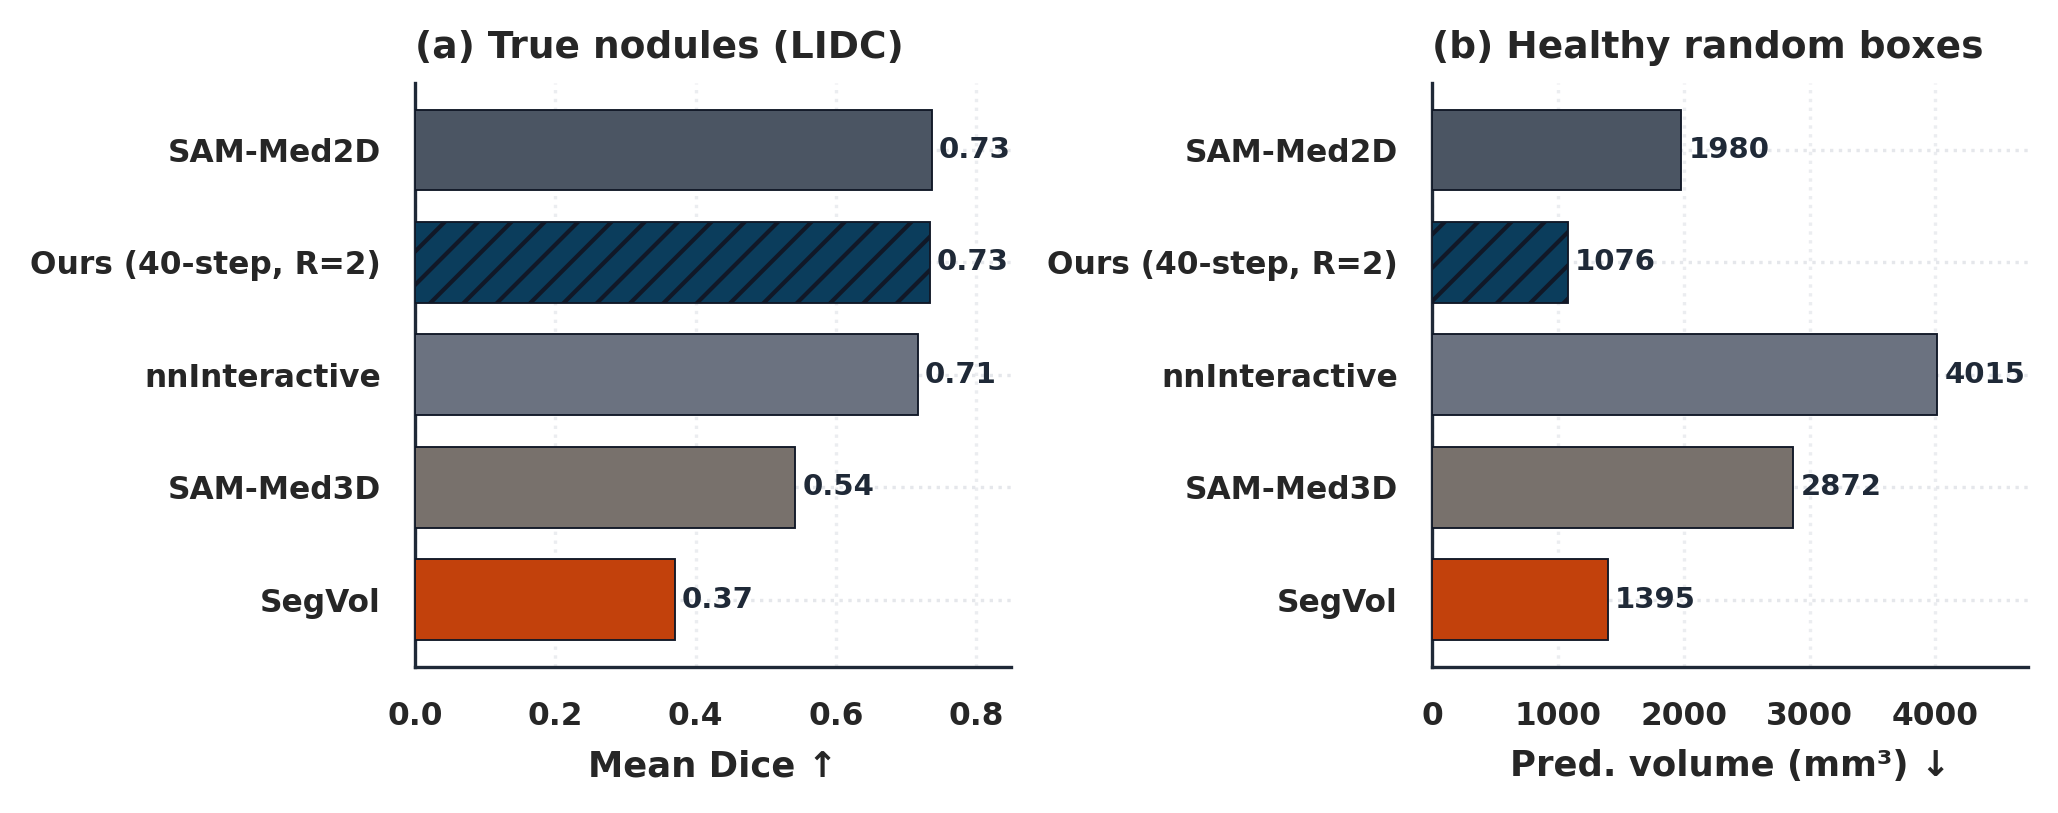

#### `seaborn_vbar` (1 png, 1 pdf, 0 html)

`fig_results_bars/seaborn_vbar/fig_results_bars.png`

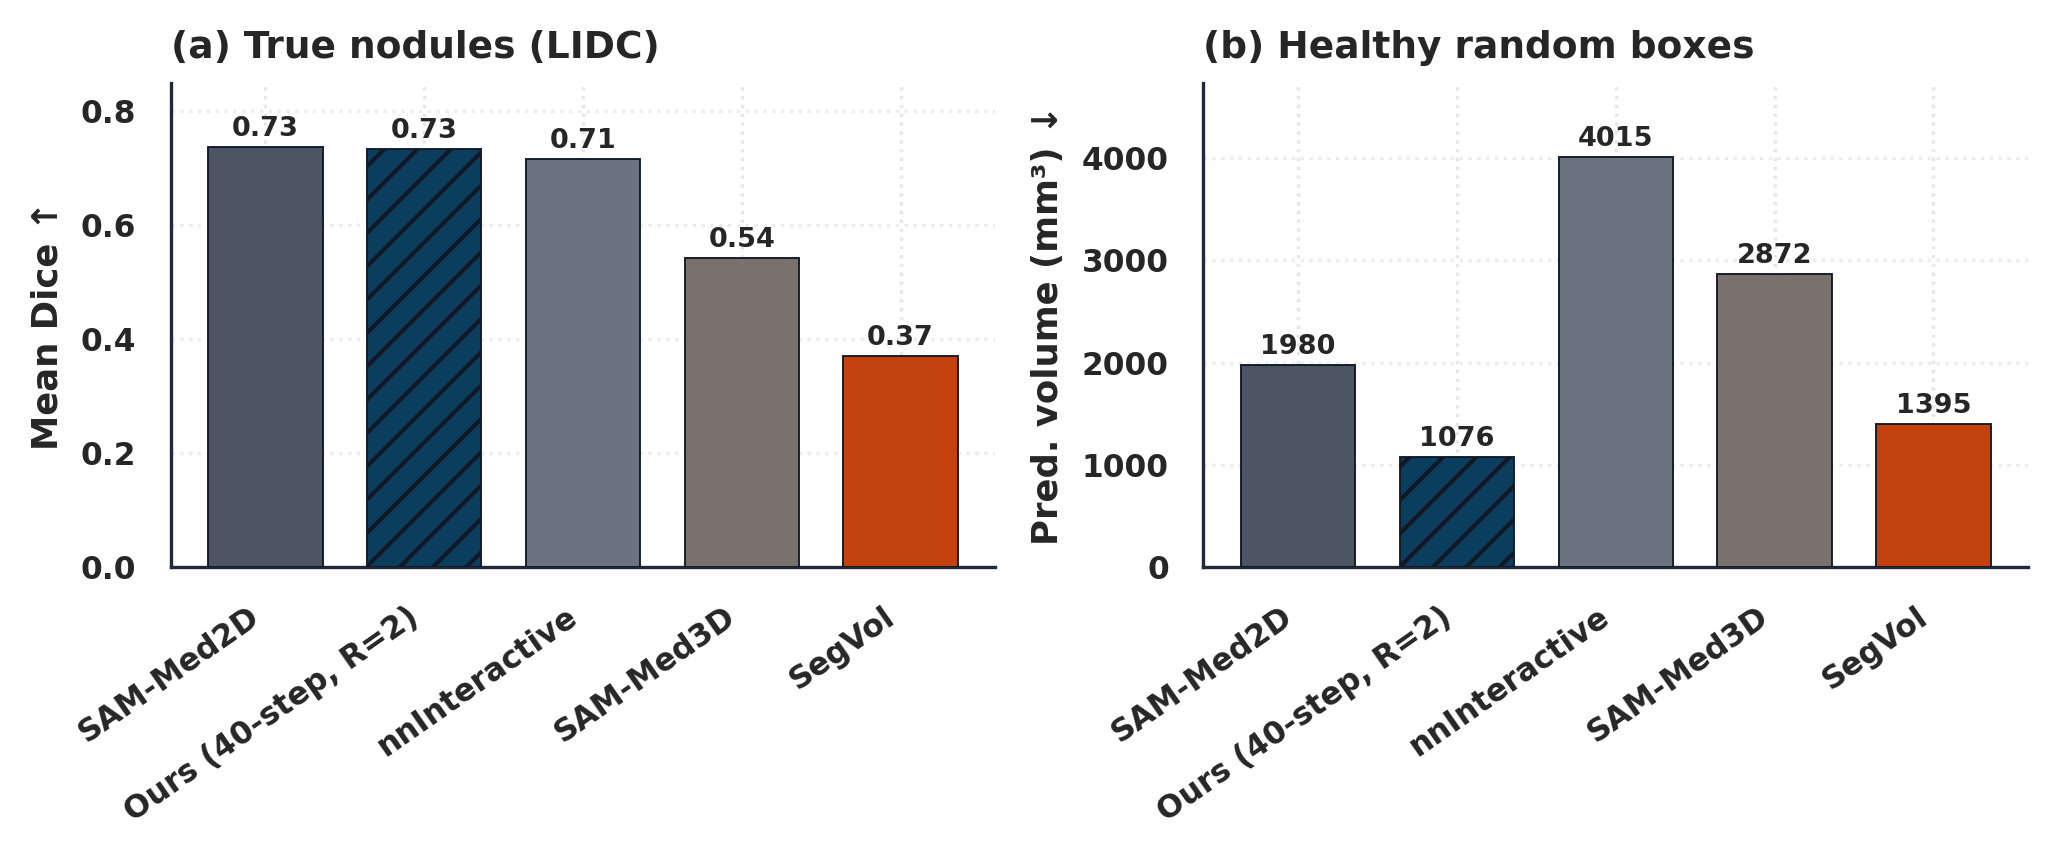

### [P0] `fig_healthy_fp`

#### `plotly` (0 png, 0 pdf, 1 html)

#### `seaborn_hbar` (1 png, 1 pdf, 0 html)

`fig_healthy_fp/seaborn_hbar/fig_healthy_fp.png`

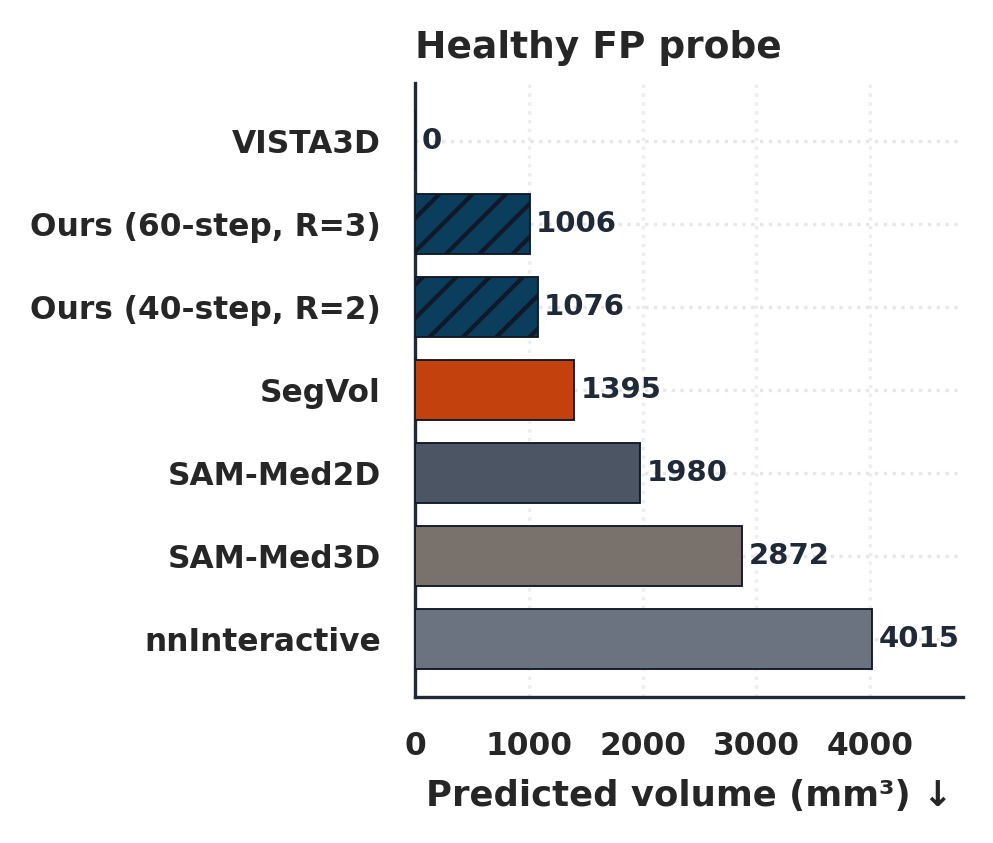

#### `seaborn_vbar` (1 png, 1 pdf, 0 html)

`fig_healthy_fp/seaborn_vbar/fig_healthy_fp.png`

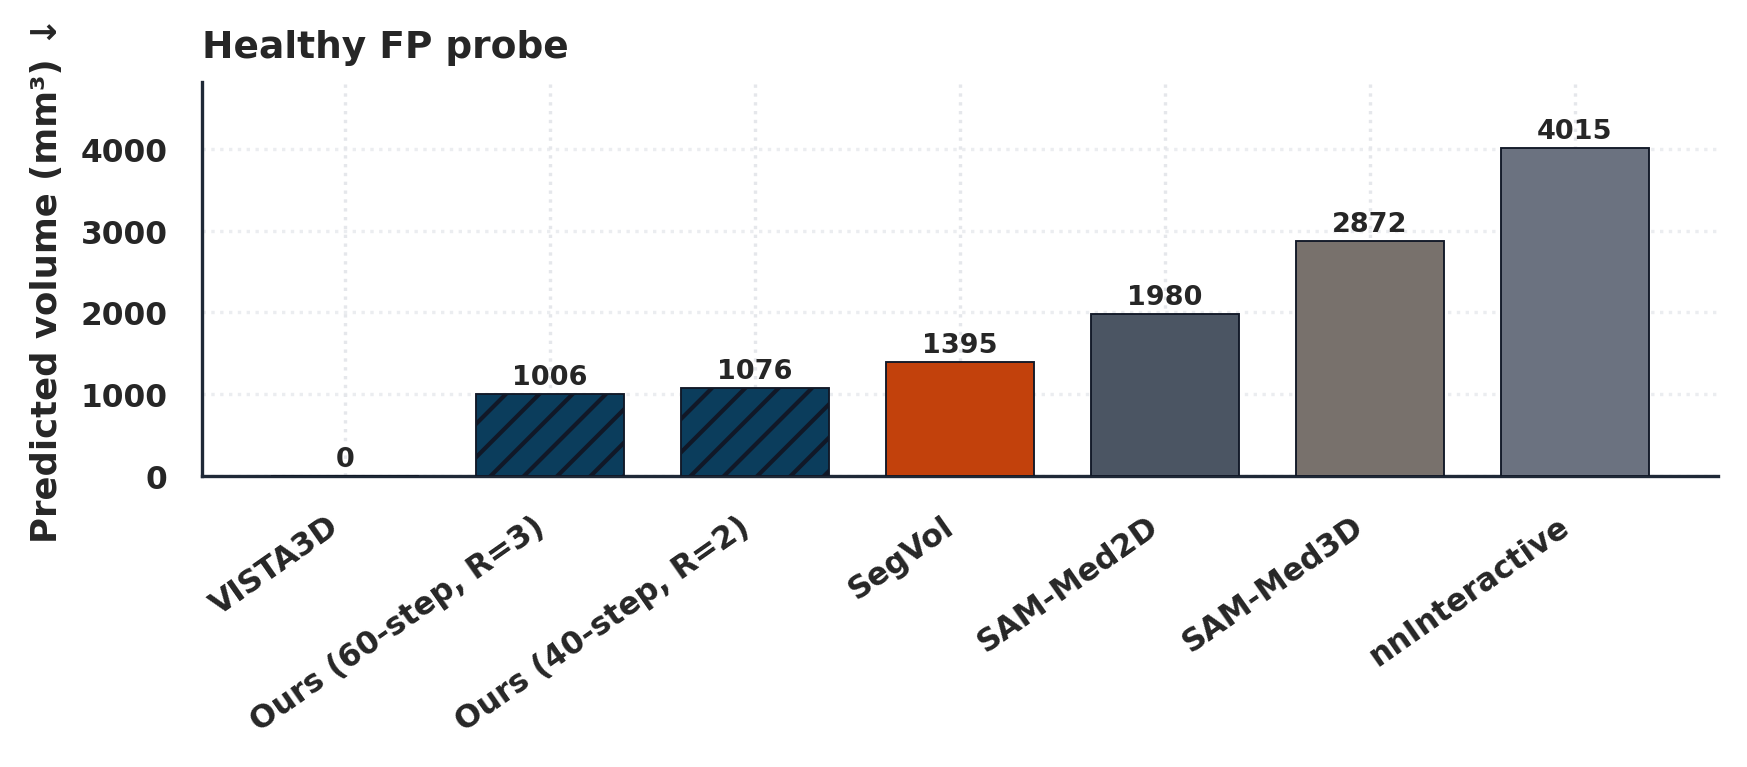

### [P1] `fig_healthy_fp_tradeoff`

#### `plotly` (0 png, 0 pdf, 1 html)

#### `seaborn_hbar` (1 png, 1 pdf, 0 html)

`fig_healthy_fp_tradeoff/seaborn_hbar/fig_healthy_fp_tradeoff.png`

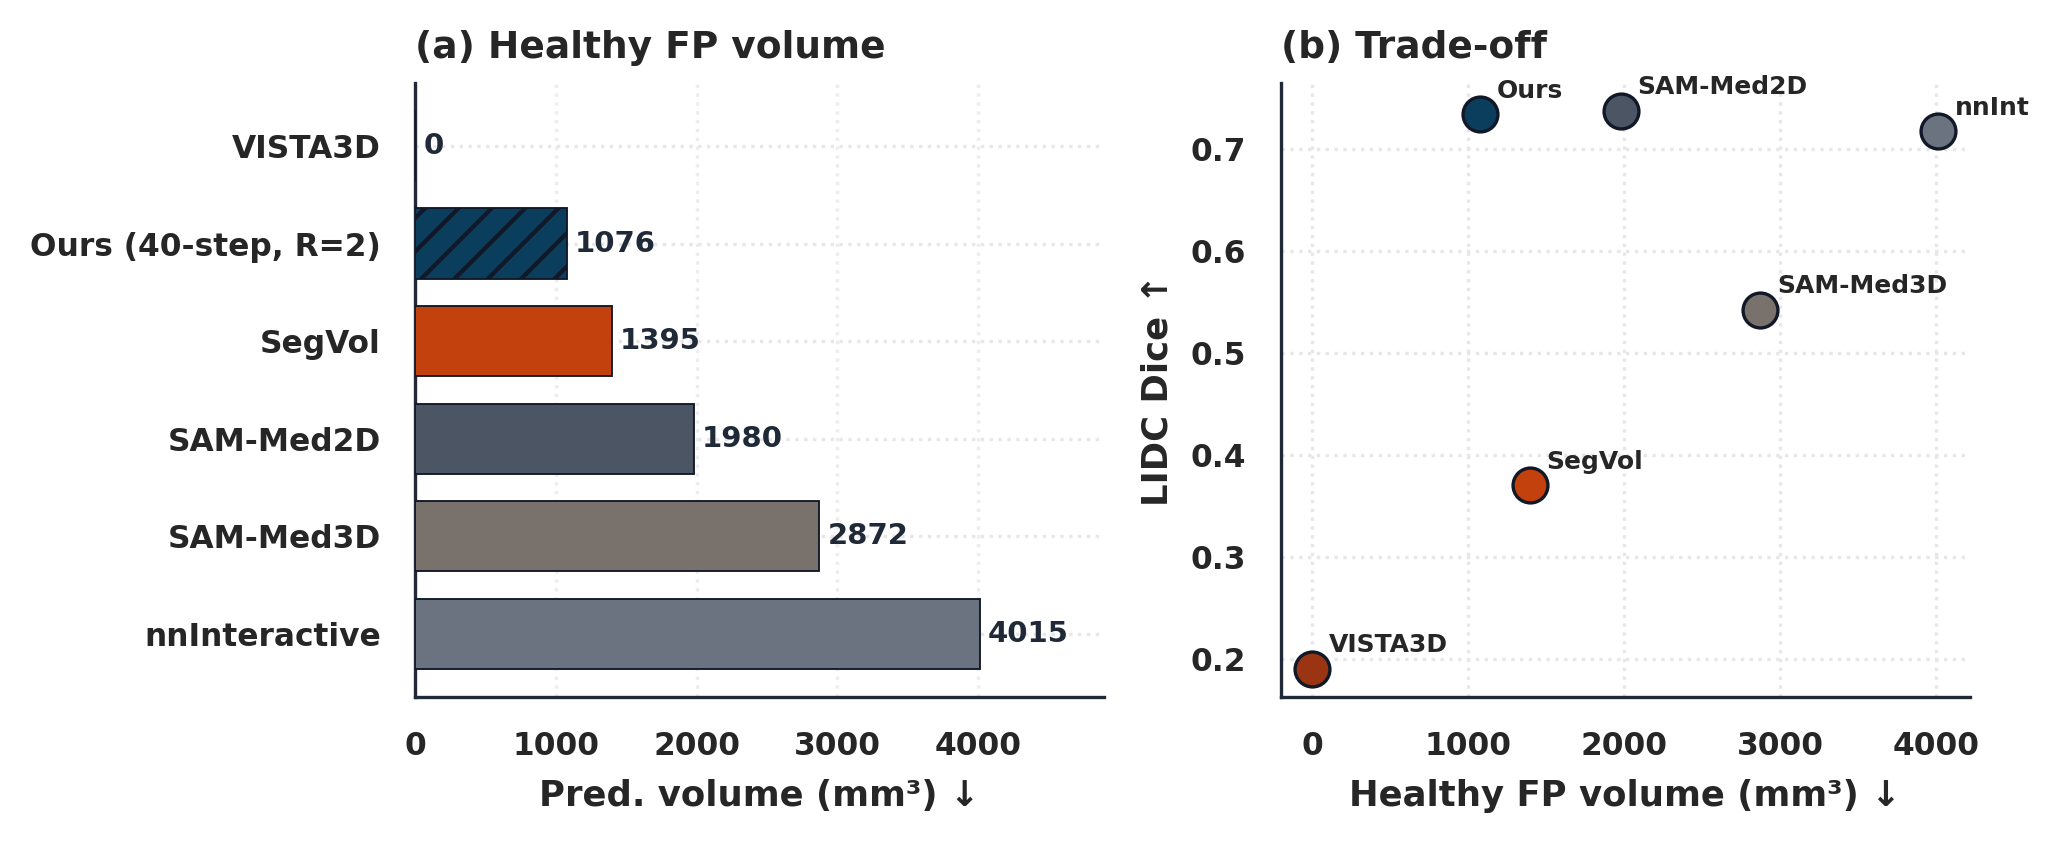

#### `seaborn_scatter` (1 png, 1 pdf, 0 html)

`fig_healthy_fp_tradeoff/seaborn_scatter/fig_healthy_fp_tradeoff.png`

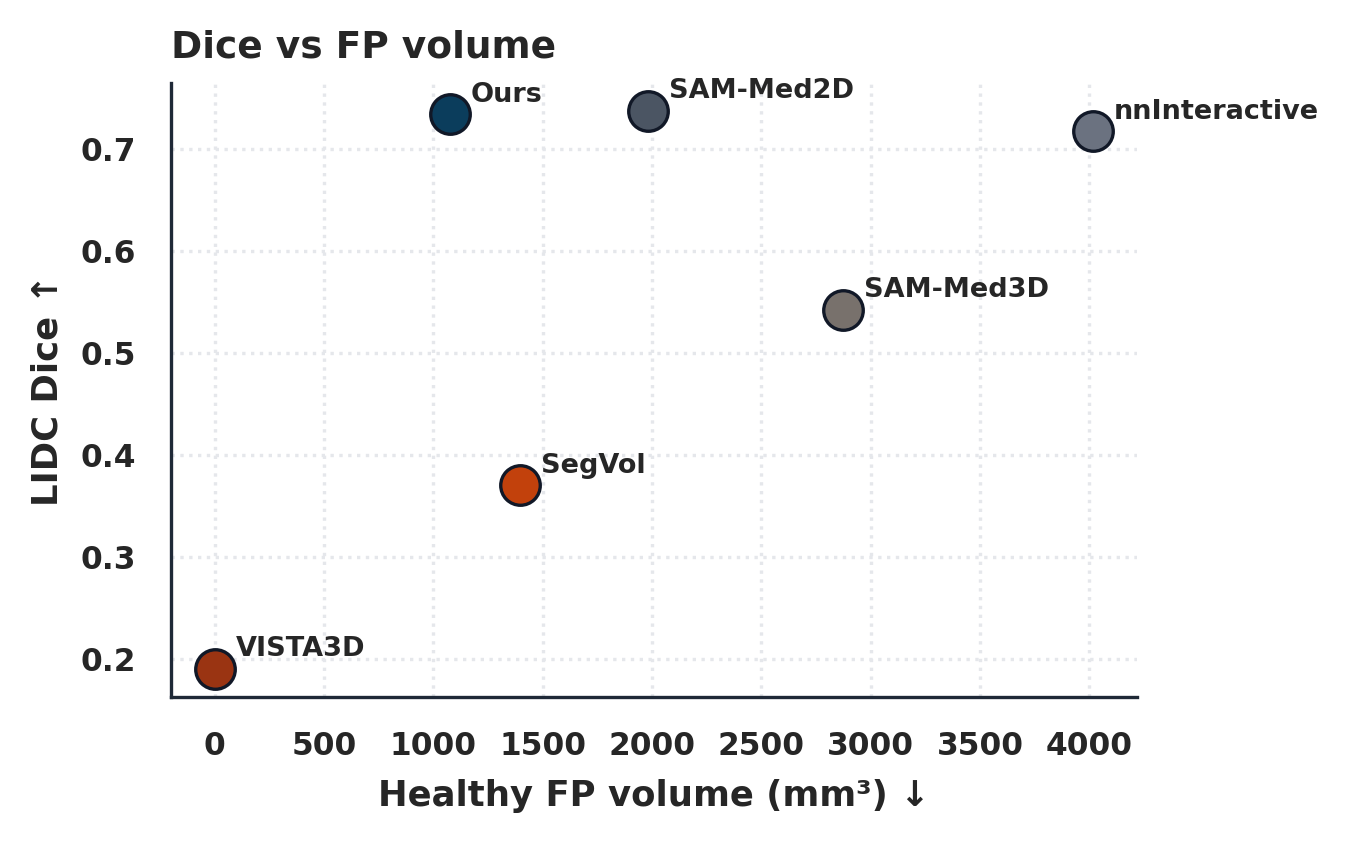

### [P1] `fig_benchmark_dice_3datasets`

#### `plotly` (0 png, 0 pdf, 1 html)

#### `seaborn_facet` (1 png, 1 pdf, 0 html)

`fig_benchmark_dice_3datasets/seaborn_facet/fig_benchmark_dice_3datasets.png`

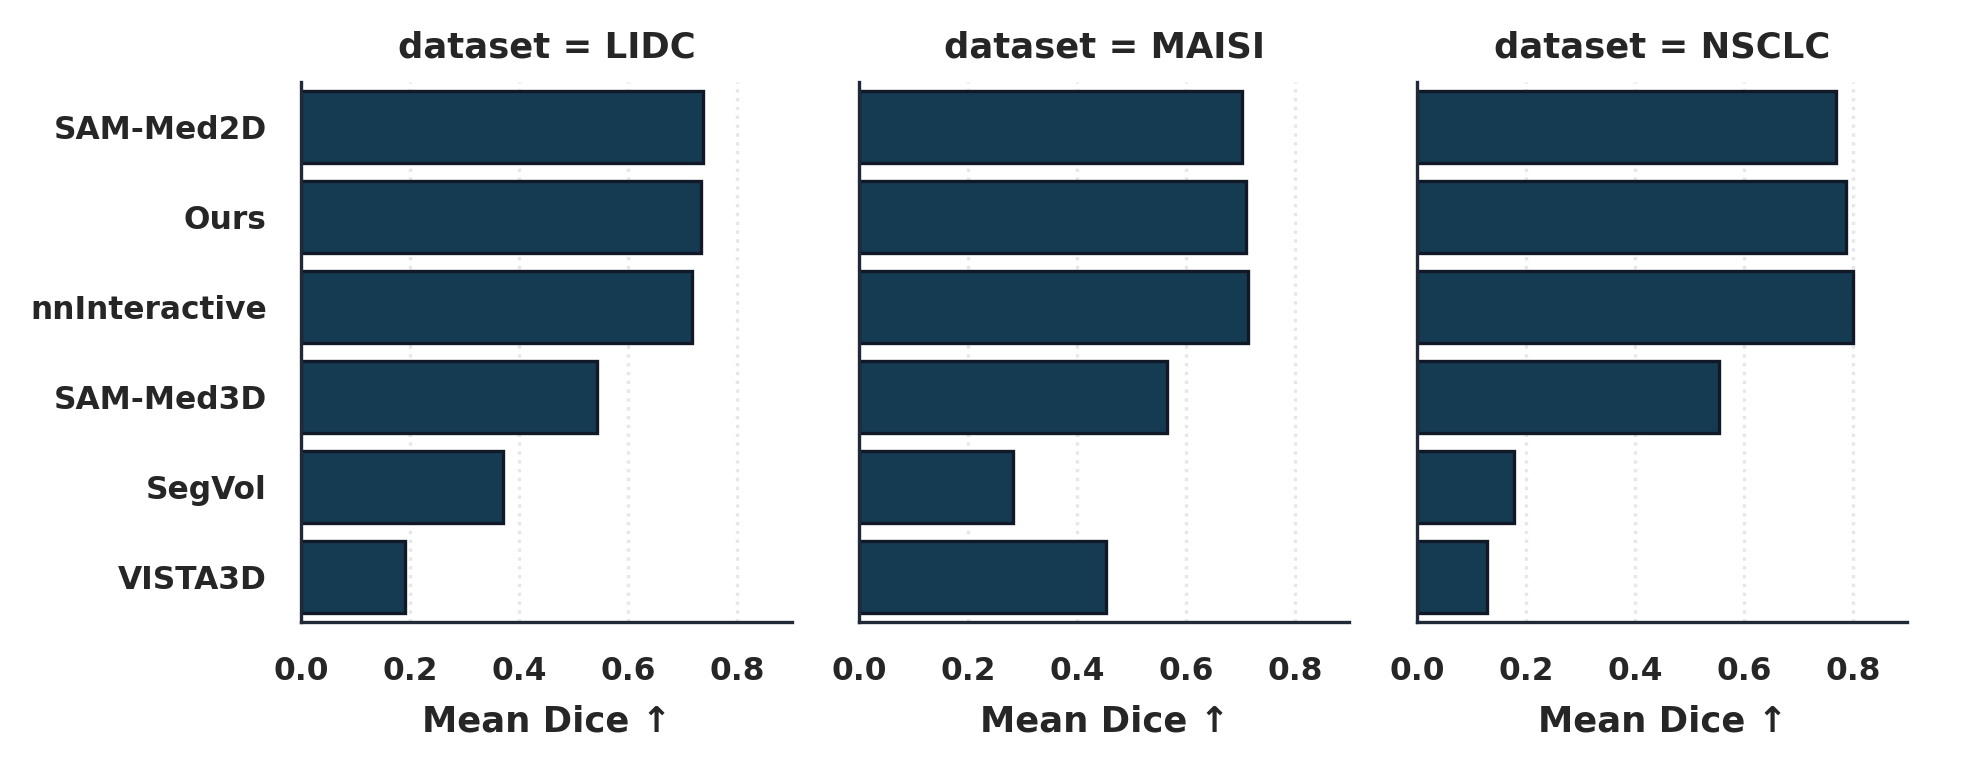

#### `seaborn_grouped` (1 png, 1 pdf, 0 html)

`fig_benchmark_dice_3datasets/seaborn_grouped/fig_benchmark_dice_3datasets.png`

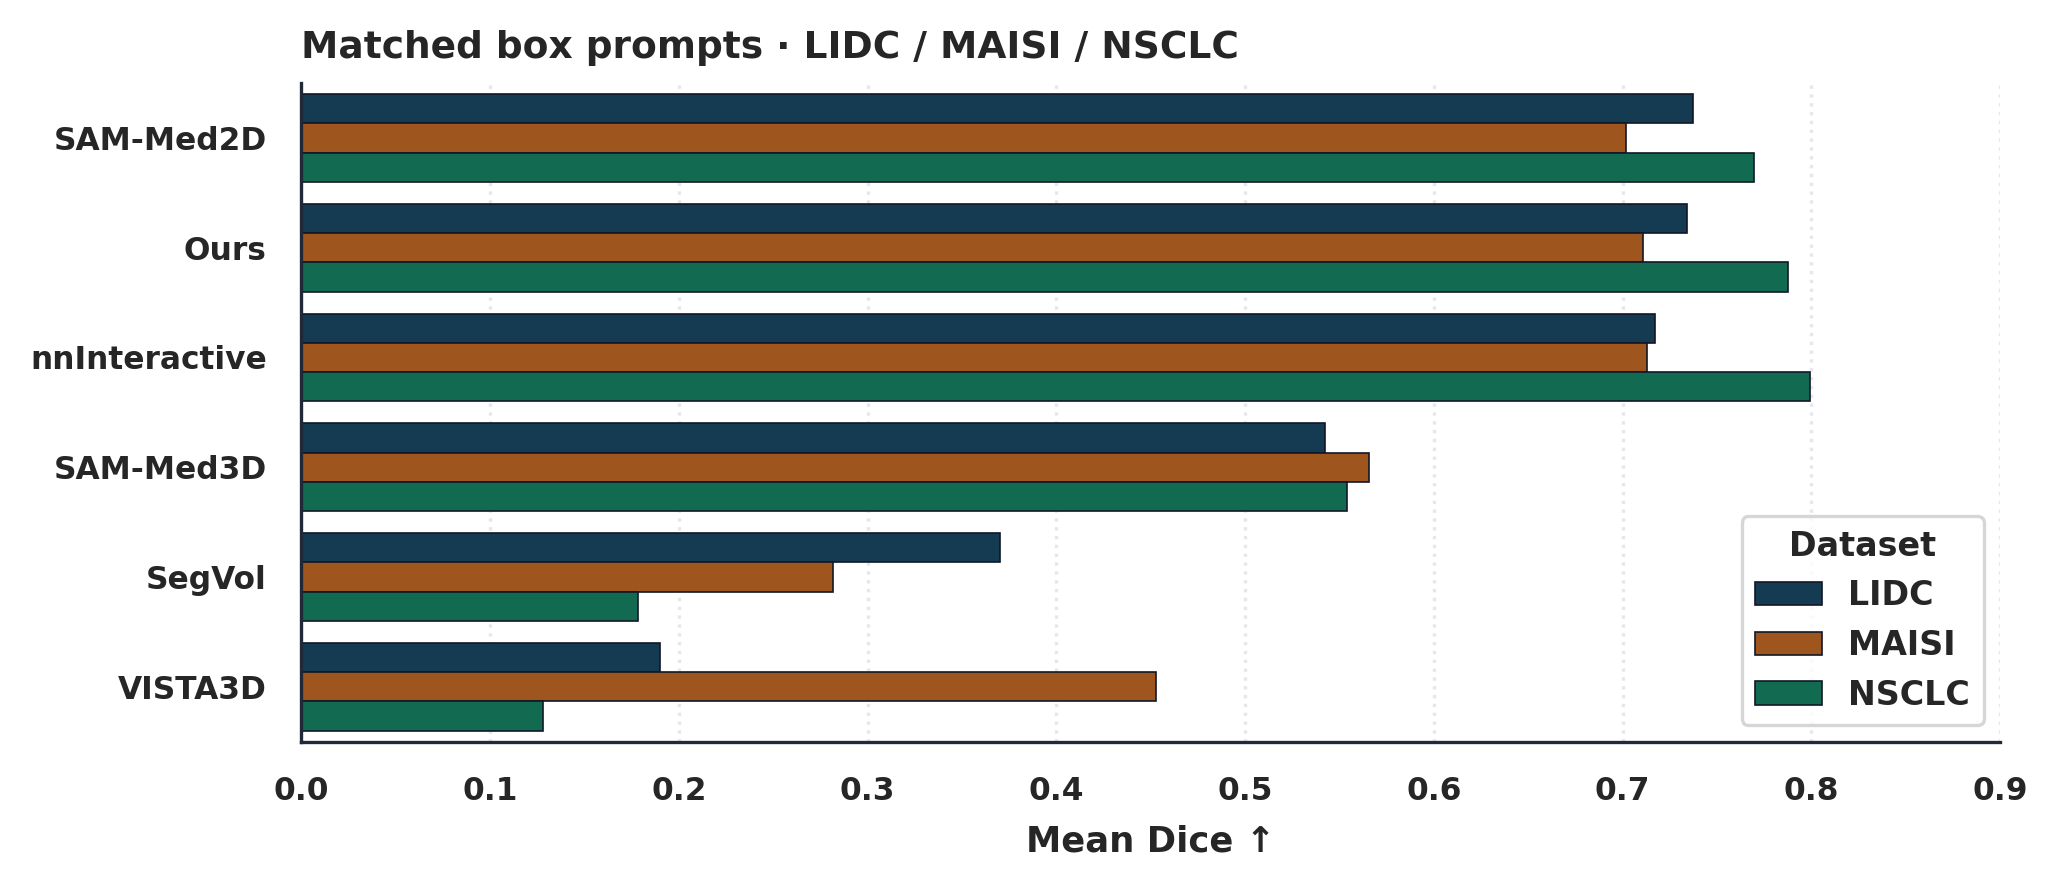

### [P1] `fig_benchmark_dice_per_dataset` — *missing*

### [P1] `fig_ablation_steps`

#### `plotly` (0 png, 0 pdf, 1 html)

#### `seaborn_hbar` (1 png, 1 pdf, 0 html)

`fig_ablation_steps/seaborn_hbar/fig_ablation_steps.png`

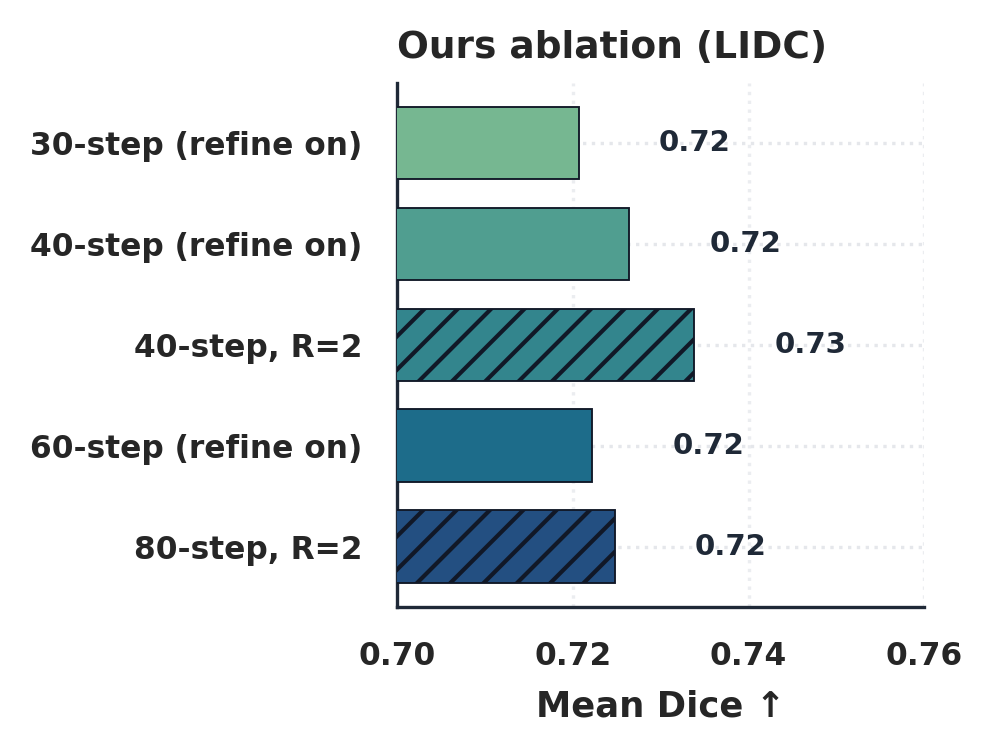

#### `seaborn_vbar` (1 png, 1 pdf, 0 html)

`fig_ablation_steps/seaborn_vbar/fig_ablation_steps.png`

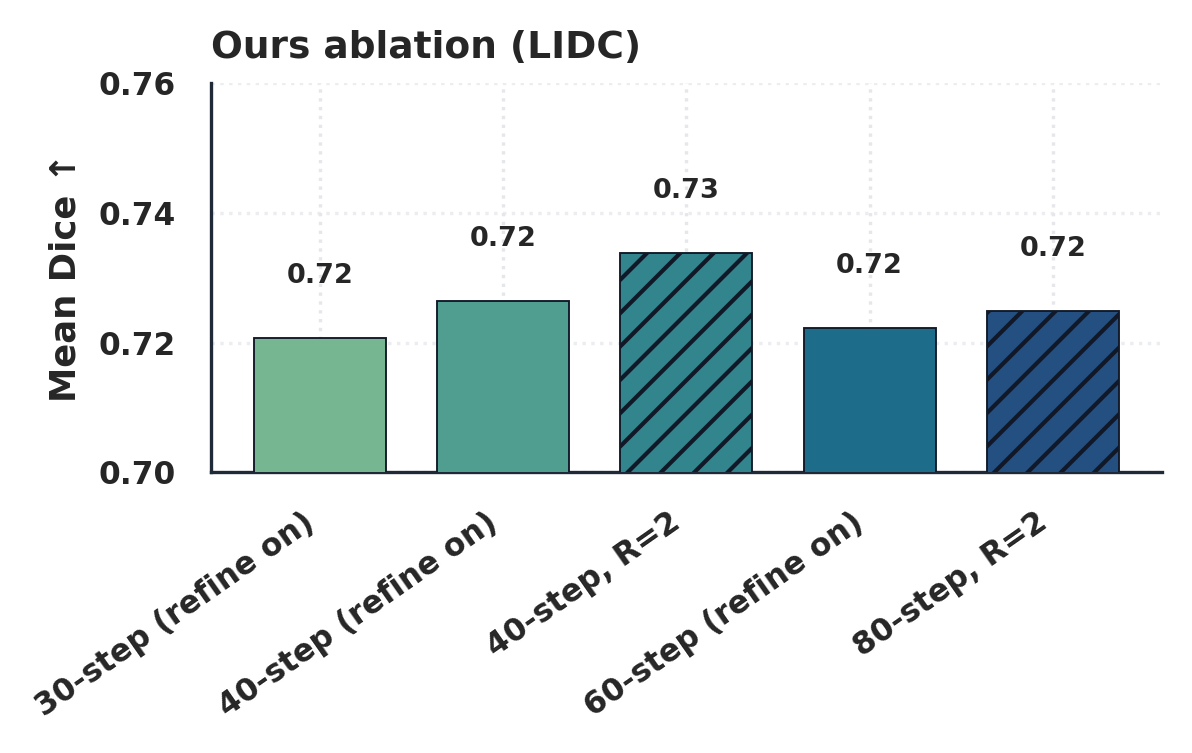

### Bake-off inventory

,priority,stem,tool,png,pdf,html
0,P0,fig_results_bars,plotly,0,0,1
1,P0,fig_results_bars,seaborn_hbar,1,1,0
2,P0,fig_results_bars,seaborn_vbar,1,1,0
3,P0,fig_healthy_fp,plotly,0,0,1
4,P0,fig_healthy_fp,seaborn_hbar,1,1,0
5,P0,fig_healthy_fp,seaborn_vbar,1,1,0
6,P1,fig_healthy_fp_tradeoff,plotly,0,0,1
7,P1,fig_healthy_fp_tradeoff,seaborn_hbar,1,1,0
8,P1,fig_healthy_fp_tradeoff,seaborn_scatter,1,1,0
9,P1,fig_benchmark_dice_3datasets,plotly,0,0,1


### Method overview sources

- `PREVIEW_mermaid.md`
- `fig_method_overview.d2`
- `fig_method_overview.dot`
- `fig_method_overview.mmd`
- `fig_method_overview.tikz.tex`

In [36]:
BAKEOFF = FIG_DIR / "bakeoff"
STEMS_BAKEOFF = [
    ("P0", "fig_results_bars"),
    ("P0", "fig_healthy_fp"),
    ("P1", "fig_healthy_fp_tradeoff"),
    ("P1", "fig_benchmark_dice_3datasets"),
    ("P1", "fig_benchmark_dice_per_dataset"),
    ("P1", "fig_ablation_steps"),
]

if not BAKEOFF.is_dir():
    display(Markdown(
        f"**Bake-off folder missing:** `{BAKEOFF}` — run the regenerate cell below."
    ))
else:
    display(Markdown(f"**Root:** `{BAKEOFF}`"))
    rows = []
    for pri, stem in STEMS_BAKEOFF:
        stem_dir = BAKEOFF / stem
        if not stem_dir.is_dir():
            display(Markdown(f"### [{pri}] `{stem}` — *missing*"))
            continue
        display(Markdown(f"### [{pri}] `{stem}`"))
        tool_dirs = sorted([p for p in stem_dir.iterdir() if p.is_dir()])
        for tool_dir in tool_dirs:
            pngs = sorted(tool_dir.glob("*.png"))
            htmls = sorted(tool_dir.glob("*.html"))
            pdfs = sorted(tool_dir.glob("*.pdf"))
            display(Markdown(
                f"#### `{tool_dir.name}` "
                f"({len(pngs)} png, {len(pdfs)} pdf, {len(htmls)} html)"
            ))
            for png in pngs:
                display(Markdown(f"`{png.relative_to(BAKEOFF)}`"))
                display(Image(filename=str(png), width=720))
            for html in htmls:
                rel = html.relative_to(PAPER)
                display(HTML(
                    f'<p><a href="{html.as_uri()}" target="_blank">'
                    f'Open Plotly: {rel}</a></p>'
                ))
            rows.append({
                "priority": pri,
                "stem": stem,
                "tool": tool_dir.name,
                "png": len(pngs),
                "pdf": len(pdfs),
                "html": len(htmls),
            })
    if rows:
        display(Markdown("### Bake-off inventory"))
        display(pd.DataFrame(rows))

    # Method schematic sources (text tools)
    method_dir = BAKEOFF / "method_overview"
    if method_dir.is_dir():
        files = sorted(p.name for p in method_dir.iterdir() if p.is_file())
        display(Markdown("### Method overview sources"))
        display(Markdown("\n".join(f"- `{f}`" for f in files)))


### Regenerate bake-off (optional)


In [37]:
import sys
# Optional: regenerate all bake-off variants (Seaborn + Plotly)
import subprocess
script = BAKEOFF / "generate_bakeoff.py"
if not script.is_file():
    script = FIG_DIR / "bakeoff" / "generate_bakeoff.py"
print("Running:", script)
proc = subprocess.run(
    [sys.executable, str(script)],
    cwd=str(script.parent),
    capture_output=True,
    text=True,
)
print(proc.stdout[-2000:] if proc.stdout else "")
if proc.returncode != 0:
    print(proc.stderr[-2000:] if proc.stderr else "")
    raise RuntimeError(f"bake-off failed with code {proc.returncode}")
print("Done — re-run the gallery cell above to refresh previews.")


Running: /home/morteza/MortezaStudentsS02/VAE_Conrol_NET/Hojjat-AAAI-2027/figures/bakeoff/generate_bakeoff.py


_steps.png, fig_ablation_steps.svg
          fig_ablation_steps    seaborn_vbar                               fig_ablation_steps.pdf, fig_ablation_steps.png, fig_ablation_steps.svg
fig_benchmark_dice_3datasets          plotly                                                                    fig_benchmark_dice_3datasets.html
fig_benchmark_dice_3datasets   seaborn_facet fig_benchmark_dice_3datasets.pdf, fig_benchmark_dice_3datasets.png, fig_benchmark_dice_3datasets.svg
fig_benchmark_dice_3datasets seaborn_grouped fig_benchmark_dice_3datasets.pdf, fig_benchmark_dice_3datasets.png, fig_benchmark_dice_3datasets.svg
              fig_healthy_fp          plotly                                                                                  fig_healthy_fp.html
              fig_healthy_fp    seaborn_hbar                                           fig_healthy_fp.pdf, fig_healthy_fp.png, fig_healthy_fp.svg
              fig_healthy_fp    seaborn_vbar                                           fi

## 3. Figure — Combined results (**P0**, `fig_results_bars`)

Primary Experiments figure: (a) LIDC true-nodule Dice; (b) healthy FP predicted volume.


Wrote: figures/fig_results_bars.pdf, figures/fig_results_bars.svg, figures/fig_results_bars.png


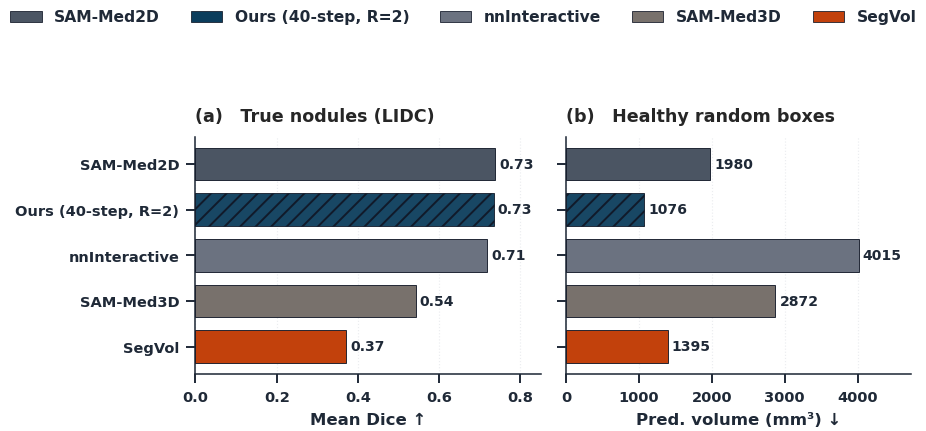

In [38]:
STEM = "fig_results_bars"

common_order = [
    "SAM-Med2D",
    "Ours (40-step, R=2)",
    "nnInteractive",
    "SAM-Med3D",
    "SegVol",
]
dice_map = dict(zip(df_lidc_plot["method"], df_lidc_plot["dice"]))
fp_map = dict(zip(df_fp["method"], df_fp["volume_mm3"]))
labels = [m for m in common_order if m in dice_map and m in fp_map]
dice_vals = [dice_map[m] for m in labels]
fp_vals = [fp_map[m] for m in labels]
colors = [METHOD_COLORS.get(m, "#6B7280") for m in labels]

fig, axes = plt.subplots(1, 2, figsize=(AAAI["double_w"], 2.85), sharey=True)
hbar(
    axes[0], labels, dice_vals, colors=colors, xlabel="Mean Dice ↑",
    xlim=(0, 0.85), title="(a) True nodules (LIDC)",
)
hbar(
    axes[1], labels, fp_vals, colors=colors, xlabel="Pred. volume (mm³) ↓",
    xlim=(0, max(fp_vals) * 1.18), value_fmt="{:.0f}",
    title="(b) Healthy random boxes",
)
# Avoid crowding: method names only on (a); panel letter is part of each title.
axes[1].tick_params(axis="y", labelleft=False)

leg = fig.legend(
    handles=method_legend_handles(labels),
    loc="upper center", ncol=min(5, len(labels)),
    bbox_to_anchor=(0.5, 1.14), frameon=False,
    prop={"weight": "bold", "size": AAAI["fs_legend"]},
)
bold_legend(leg)
fig.tight_layout(rect=(0.02, 0.02, 0.98, 0.90))
save_fig(fig, STEM)
plt.show()


## 4. Figure — Healthy FP volume (**P0**, `fig_healthy_fp`)

Standalone healthy false-positive probe (mean predicted volume, mm³).


Wrote: figures/fig_healthy_fp.pdf, figures/fig_healthy_fp.svg, figures/fig_healthy_fp.png


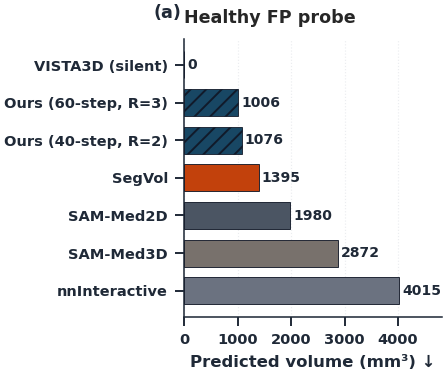

In [39]:
STEM = "fig_healthy_fp"

ORDER_FP = [
    "VISTA3D",
    "Ours (60-step, R=3)",
    "Ours (40-step, R=2)",
    "SegVol",
    "SAM-Med2D",
    "SAM-Med3D",
    "nnInteractive",
]
dfp = df_fp.set_index("method").reindex([m for m in ORDER_FP if m in set(df_fp["method"])]).reset_index()
labels = dfp["method"].tolist()
# Keep note on the axis label (no floating callout inside the plot)
labels_plot = [
    ("VISTA3D (silent)" if m == "VISTA3D" else m) for m in labels
]
vols = dfp["volume_mm3"].tolist()
colors = [METHOD_COLORS.get(m, "#9CA3AF" if m == "VISTA3D" else "#6B7280") for m in labels]

fig, ax = plt.subplots(figsize=(AAAI["single_w"], 2.85))
hbar(
    ax, labels_plot, vols, colors=colors,
    xlabel="Predicted volume (mm³) ↓",
    xlim=(0, max(vols) * 1.20),
    value_fmt="{:.0f}",
    title="Healthy FP probe",
    highlight="Ours",
)
panel_label(ax, "(a)", x=-0.12, y=1.06)
fig.tight_layout()
save_fig(fig, STEM)
plt.show()


## 5. Figure — Healthy FP ↔ LIDC trade-off (**P1**, `fig_healthy_fp_tradeoff`)

(a) FP volume bars; (b) LIDC Dice vs healthy FP volume plane.


,method,fp_volume,lidc_dice,silent
0,VISTA3D,0.000000,0.19,True
1,"Ours (40-step, R=2)",1075.666375,0.73,False
2,SegVol,1395.482867,0.37,False
3,SAM-Med2D,1980.431086,0.73,False
4,SAM-Med3D,2872.272047,0.54,False
5,nnInteractive,4014.930609,0.71,False


Wrote: figures/fig_healthy_fp_tradeoff.pdf, figures/fig_healthy_fp_tradeoff.svg, figures/fig_healthy_fp_tradeoff.png


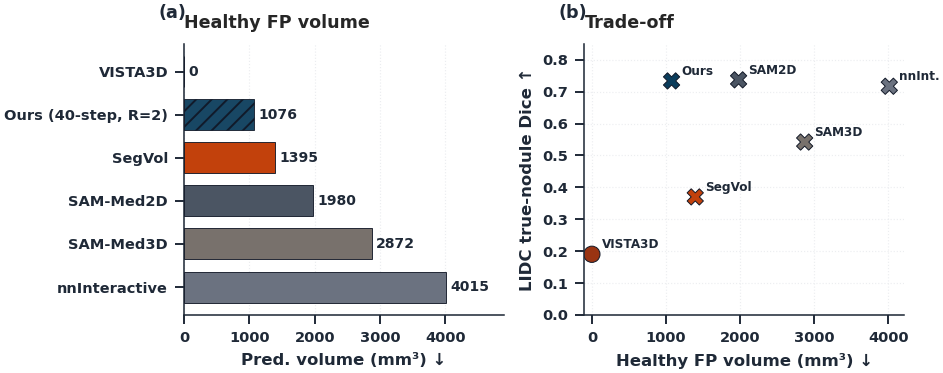

In [40]:
STEM = "fig_healthy_fp_tradeoff"

ORDER = [
    "VISTA3D",
    "Ours (40-step, R=2)",
    "SegVol",
    "SAM-Med2D",
    "SAM-Med3D",
    "nnInteractive",
]
fp_map = dict(zip(df_fp["method"], df_fp["volume_mm3"]))
dice_src = df_lidc_plot if "df_lidc_plot" in globals() else df_lidc
dice_map = dict(zip(dice_src["method"], dice_src["dice"]))
if "Ours" in dice_map and "Ours (40-step, R=2)" not in dice_map:
    dice_map["Ours (40-step, R=2)"] = dice_map["Ours"]

rows = []
for m in ORDER:
    if m not in fp_map:
        continue
    rows.append({
        "method": m,
        "fp_volume": float(fp_map[m]),
        "lidc_dice": float(dice_map.get(m, np.nan)),
        "silent": float(fp_map[m]) <= 1e-6,
    })
df_trade = pd.DataFrame(rows)
display(cut_df(df_trade, cols=["lidc_dice"]))

fig, axes = plt.subplots(1, 2, figsize=(AAAI["double_w"], 2.85))

df_vol = df_trade.sort_values("fp_volume").reset_index(drop=True)
cols = [("#9CA3AF" if r.silent else METHOD_COLORS.get(r.method, "#6B7280")) for r in df_vol.itertuples()]
hbar(
    axes[0], df_vol["method"].tolist(), df_vol["fp_volume"].tolist(),
    colors=cols, xlabel="Pred. volume (mm³) ↓",
    xlim=(0, max(df_vol["fp_volume"]) * 1.22),
    value_fmt="{:.0f}", title="Healthy FP volume",
)
panel_label(axes[0], "(a)")

ax = axes[1]
plot_df = df_trade.dropna(subset=["lidc_dice"]).copy()
plot_df["style"] = np.where(plot_df["silent"], "silent", "active")
sns.scatterplot(
    data=plot_df, x="fp_volume", y="lidc_dice",
    hue="method", style="style",
    palette={m: METHOD_COLORS.get(m, "#6B7280") for m in plot_df["method"]},
    s=70, edgecolor=C["bar_edge"], linewidth=0.5, ax=ax, legend=False,
)
for r in plot_df.itertuples():
    short = (
        r.method.replace("Ours (40-step, R=2)", "Ours")
        .replace("nnInteractive", "nnInt.")
        .replace("SAM-Med2D", "SAM2D")
        .replace("SAM-Med3D", "SAM3D")
    )
    ax.annotate(short, (r.fp_volume, r.lidc_dice),
                textcoords="offset points", xytext=(5, 3),
                fontsize=6.2, color=C["spine"])
ax.set_xlabel("Healthy FP volume (mm³) ↓")
ax.set_ylabel("LIDC true-nodule Dice ↑")
ax.set_title("Trade-off", loc="left", pad=8, fontweight="bold")
ax.set_xlim(left=-100)
ax.set_ylim(0, 0.85)
ax.grid(True, linestyle=":", alpha=0.7)
sns.despine(ax=ax)
panel_label(ax, "(b)")

fig.tight_layout()
save_fig(fig, STEM)
plt.show()


## 6. Multi-dataset Dice (**P1**)

Split into two camera-ready figures (avoids overlapping labels):

| Stem | Content |
|------|---------|
| `fig_benchmark_dice_3datasets` | Grouped LIDC / MAISI / NSCLC (paper `fig:bench`) |
| `fig_benchmark_dice_per_dataset` | One panel per dataset with full method labels |


Wrote: figures/fig_benchmark_dice_3datasets.pdf, figures/fig_benchmark_dice_3datasets.svg, figures/fig_benchmark_dice_3datasets.png


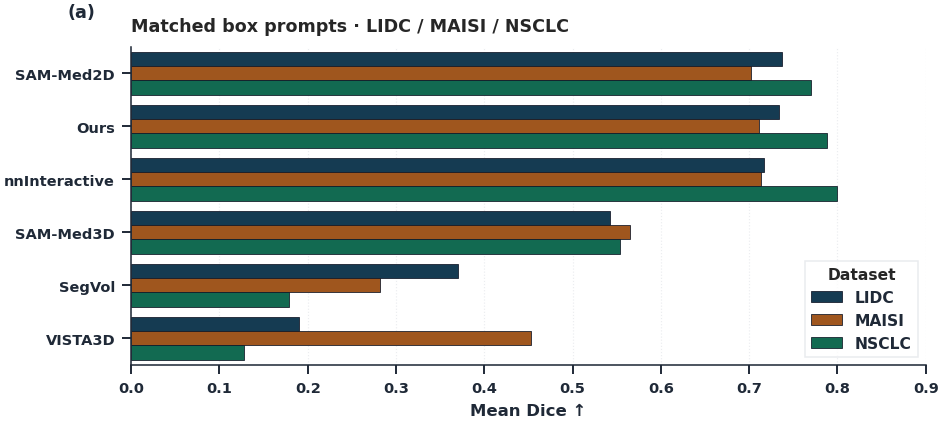

Wrote: figures/fig_benchmark_dice_per_dataset.pdf, figures/fig_benchmark_dice_per_dataset.svg, figures/fig_benchmark_dice_per_dataset.png


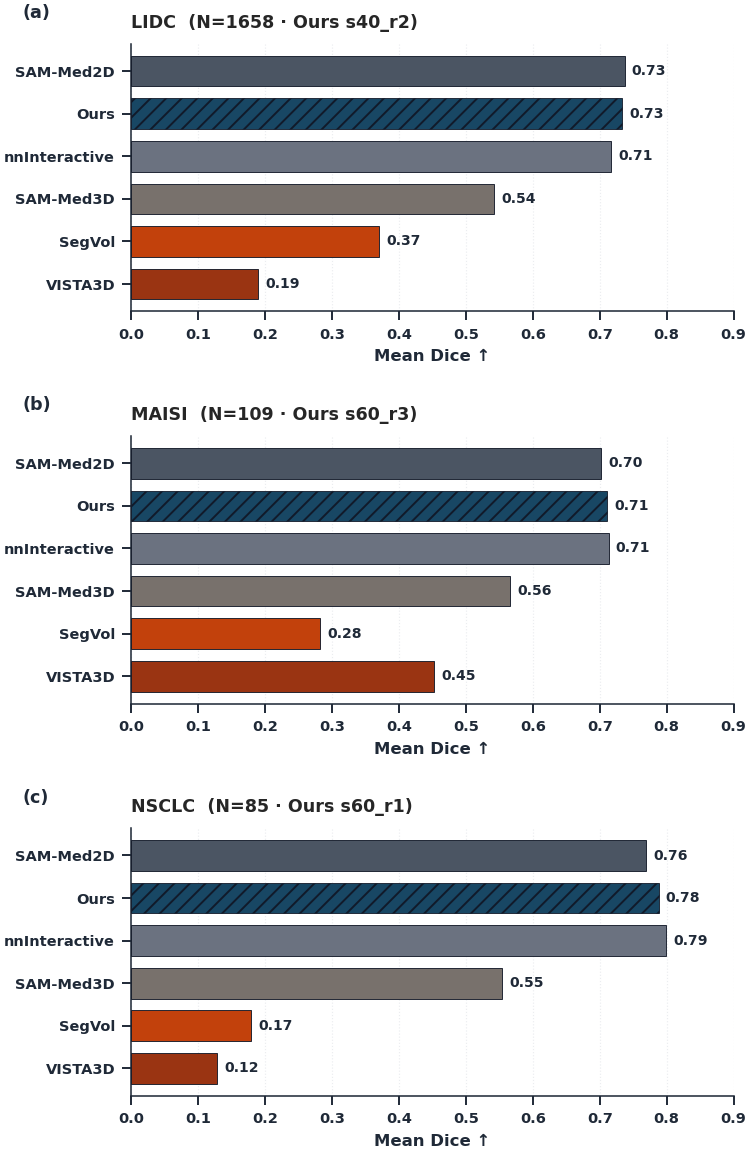

dataset,LIDC,MAISI,NSCLC
method,,,
SAM-Med2D,0.73,0.70,0.76
Ours,0.73,0.71,0.78
nnInteractive,0.71,0.71,0.79
SAM-Med3D,0.54,0.56,0.55
SegVol,0.37,0.28,0.17
VISTA3D,0.19,0.45,0.12


Wrote separate figures: `fig_benchmark_dice_3datasets` (grouped) and `fig_benchmark_dice_per_dataset` (per-dataset).

In [41]:
# --- Figure A: grouped comparison (paper fig:bench) ---
STEM = "fig_benchmark_dice_3datasets"
df_long = df_bench[["dataset", "method", "dice", "iou", "n_cases"]].copy()

fig, ax = plt.subplots(figsize=(AAAI["double_w"], 3.2))
grouped_hbar_datasets(ax, df_long)
ax.set_title("Matched box prompts · LIDC / MAISI / NSCLC", loc="left", pad=8, fontweight="bold")
panel_label(ax, "(a)")
fig.tight_layout()
save_fig(fig, STEM)
plt.show()

# --- Figure B: per-dataset panels (separate file, more vertical space) ---
STEM_B = "fig_benchmark_dice_per_dataset"
panels = [
    ("LIDC", df_lidc, "N=1658 · Ours s40_r2"),
    ("MAISI", df_maisi, "N=109 · Ours s60_r3"),
    ("NSCLC", df_nsclc, "N=85 · Ours s60_r1"),
]

fig, axes = plt.subplots(3, 1, figsize=(AAAI["single_w"] * 1.65, 8.4), sharex=False)
for i, (name, df, note) in enumerate(panels):
    ax = axes[i]
    dfo = df.set_index("method").reindex(METHOD_ORDER).reset_index()
    cols = [METHOD_COLORS.get(m, "#6B7280") for m in dfo["method"]]
    hbar(
        ax, dfo["method"].tolist(), dfo["dice"].tolist(),
        colors=cols,
        xlabel="Mean Dice ↑",
        xlim=(0, 0.90), value_fmt="{:.2f}",
        title=f"{name}  ({note})",
    )
    panel_label(ax, f"({'abc'[i]})", x=-0.18, y=1.08)
    ax.tick_params(axis="y", labelsize=AAAI["fs_tick"])

fig.tight_layout(h_pad=2.2)
save_fig(fig, STEM_B)
plt.show()

cut_df(df_bench_pivot).to_csv(FIG_DIR / "table_benchmark_dice_3datasets.csv")
display(cut_df(df_bench_pivot))
display(Markdown(
    f"Wrote separate figures: `{STEM}` (grouped) and `{STEM_B}` (per-dataset)."
))


## 7. Figure — Ablation (**P1**, `fig_ablation_steps`)

Inference steps and refine rounds \(R\) on LIDC positives.


Wrote: figures/fig_ablation_steps.pdf, figures/fig_ablation_steps.svg, figures/fig_ablation_steps.png


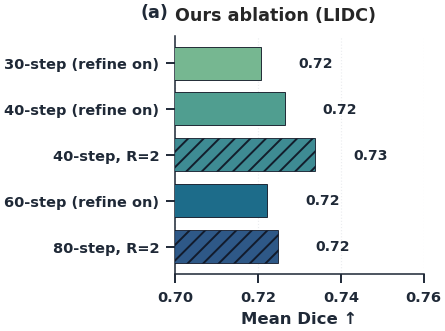

In [42]:
STEM = "fig_ablation_steps"

labels = df_ablation["config"].tolist()
dice = df_ablation["dice"].tolist()
cmap = sns.color_palette("crest", n_colors=len(labels))

fig, ax = plt.subplots(figsize=(AAAI["single_w"], 2.55))
hbar(
    ax, labels, dice, colors=list(cmap),
    xlabel="Mean Dice ↑", xlim=(0.70, 0.76),
    value_fmt="{:.2f}", highlight="R=2",
    title="Ours ablation (LIDC)",
)
panel_label(ax, "(a)", x=-0.14, y=1.06)
fig.tight_layout()
save_fig(fig, STEM)
plt.show()


## 8. Figure — LIDC-only Dice (**P2** legacy, `fig_lidc_dice`)

Optional single-dataset bar chart; prefer §3 `fig_results_bars` for the paper.


Wrote: figures/fig_lidc_dice.pdf, figures/fig_lidc_dice.svg, figures/fig_lidc_dice.png


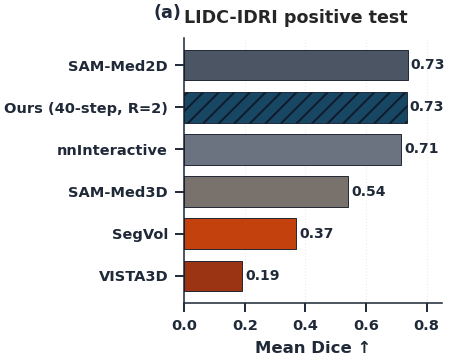

In [43]:
STEM = "fig_lidc_dice"

labels = df_lidc_plot["method"].tolist()
dice = df_lidc_plot["dice"].tolist()
colors = [METHOD_COLORS.get(m, "#6B7280") for m in labels]

fig, ax = plt.subplots(figsize=(AAAI["single_w"], 2.75))
hbar(
    ax, labels, dice, colors=colors,
    xlabel="Mean Dice ↑", xlim=(0, 0.85),
    title="LIDC-IDRI positive test",
)
panel_label(ax, "(a)", x=-0.12, y=1.06)
fig.tight_layout()
save_fig(fig, STEM)
plt.show()


## 9. Interactive Plotly exports (**P2** supplementary HTML)


In [44]:
STEM_HTML = "fig_benchmark_dice_3datasets_interactive"

if not HAS_PLOTLY:
    print("Plotly not available — skip interactive exports")
else:
    df_long = df_bench.copy()
    df_long["dice"] = cut_dp(df_long["dice"].to_numpy(), 2)
    df_long["iou"] = cut_dp(df_long["iou"].to_numpy(), 2)
    fig = px.bar(
        df_long,
        x="dice", y="method", color="dataset",
        orientation="h", barmode="group",
        category_orders={"method": METHOD_ORDER, "dataset": ["LIDC", "MAISI", "NSCLC"]},
        color_discrete_map=DATASET_COLORS,
        hover_data={"iou": ":.2f", "n_cases": True, "dice": ":.2f"},
        title="Mean Dice — LIDC / MAISI / NSCLC (interactive)",
        labels={"dice": "Mean Dice", "method": "", "dataset": "Dataset"},
        height=420, width=900,
    )
    fig.update_layout(
        template="plotly_white",
        font=dict(family="DejaVu Sans", size=12),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
        margin=dict(l=120, r=30, t=80, b=50),
        xaxis=dict(range=[0, 0.9], gridcolor="#E5E7EB"),
        bargap=0.25,
    )
    html_path = FIG_DIR / f"{STEM_HTML}.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")
    print("Wrote", html_path.relative_to(PAPER))

    fp_map = dict(zip(df_fp["method"], df_fp["volume_mm3"]))
    dice_map = dict(zip(df_lidc_plot["method"], df_lidc_plot["dice"]))
    trade_rows = []
    for m, vol in fp_map.items():
        d = dice_map.get(m, np.nan)
        if not np.isfinite(d):
            continue
        trade_rows.append({"method": m, "fp_volume": vol, "lidc_dice": d})
    tdf = pd.DataFrame(trade_rows)
    fig2 = px.scatter(
        tdf, x="fp_volume", y="lidc_dice", text="method", color="method",
        color_discrete_map=METHOD_COLORS,
        title="Healthy FP volume vs LIDC Dice (interactive)",
        labels={"fp_volume": "Healthy FP volume (mm³)", "lidc_dice": "LIDC Dice"},
        height=420, width=720,
    )
    fig2.update_traces(textposition="top right", marker=dict(size=12, line=dict(width=0.5, color="#111")))
    fig2.update_layout(template="plotly_white", showlegend=False)
    html2 = FIG_DIR / "fig_healthy_fp_tradeoff_interactive.html"
    fig2.write_html(str(html2), include_plotlyjs="cdn")
    print("Wrote", html2.relative_to(PAPER))


Wrote figures/fig_benchmark_dice_3datasets_interactive.html
Wrote figures/fig_healthy_fp_tradeoff_interactive.html


## 10. Qualitative overlays — inspect before paper (**P2**)

Camera-ready grids currently used in `main.tex` / `AAAI2027_paper.tex`  
(red = GT, lime = prediction; healthy-FP uses yellow prompt).

| Paper figure | Stem | Cases / note |
|--------------|------|----------------|
| `fig:qual-lidc` | `fig_qual_lidc` | LIDC `#1370, #76, #1183, #338` (Dice ≈ 0.93) |
| `fig:qual-fp` | `fig_qual_healthy_fp` | Healthy random boxes (sparse Ours preferred) |
| `fig:qual-cross` (top) | `fig_qual_maisi` | MAISI `#50, #9, #86, #16` (compact high-Dice) |
| `fig:qual-cross` (bottom) | `fig_qual_nsclc` (64³ patches) | `LUNG1-024 / 145 / 098 / 173` |
| `fig:qual-ablation` | `fig_qual_ablation` | LIDC `#1370, #76, #1183` |

Run the next cell to display all five inline. Regenerate (GPU) only if you change cases in `make_qualitative_paper_figures.py`.


In [ ]:
# Inspect camera-ready qualitative figures (do NOT overwrite with old viz galleries).
# CT overlays use mild windowing (p1–p99, gamma≈1) — not high-contrast black/white.
# Re-run make_qualitative_paper_figures.py if PNGs are stale.
from IPython.display import display, Image, Markdown
from datetime import datetime

PAPER_QUAL = [
    ("fig_qual_lidc", "LIDC — Ours 40-step R=2  ·  cases #1370, #76, #1183, #338"),
    ("fig_qual_healthy_fp", "Healthy FP — yellow=prompt, lime=pred (GT empty)"),
    ("fig_qual_maisi", "MAISI — Ours 60-step R=3  ·  cases #50, #9, #86, #16"),
    ("fig_qual_nsclc", "NSCLC patches 64³ — Ours 60-step R=1  ·  LUNG1-024 / 145 / 098 / 173"),
    ("fig_qual_nsclc_volume", "NSCLC volume — same patients as patch grid"),
    ("fig_qual_ablation", "Ablation (LIDC) — steps / refine  ·  #1370, #76, #1183"),
    ("fig_method_overview", "Method overview — training / inference with CT samples"),
]

for stem, title in PAPER_QUAL:
    png = FIG_DIR / f"{stem}.png"
    pdf = FIG_DIR / f"{stem}.pdf"
    if not png.is_file():
        print(f"MISSING {png.name}  (run make_qualitative_paper_figures.py / make_method_overview.py)")
        continue
    when = datetime.fromtimestamp(png.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
    size_kb = png.stat().st_size / 1024
    display(Markdown(
        f"### `{stem}`\n{title}\n\n"
        f"`{png.name}` · {size_kb:.0f} KB · mtime {when}"
        + (f" · PDF ok" if pdf.is_file() else " · **PDF missing**")
    ))
    display(Image(filename=str(png), width=980 if stem not in ("fig_qual_nsclc", "fig_method_overview") else 1100))


### Quick preview (markdown embeds — no kernel needed)

![LIDC](fig_qual_lidc.png)

![Healthy FP](fig_qual_healthy_fp.png)

![MAISI](fig_qual_maisi.png)

![NSCLC](fig_qual_nsclc.png)

![Ablation](fig_qual_ablation.png)


## 11. Method overview — draw.io / SVG (**P2**, not editable inside Cursor)


Wrote: figures/fig_method_overview.pdf, figures/fig_method_overview.svg, figures/fig_method_overview.png


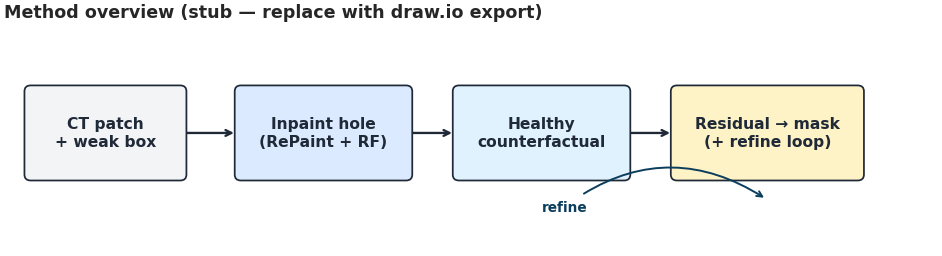

draw.io source expected at: /home/morteza/MortezaStudentsS02/VAE_Conrol_NET/Hojjat-AAAI-2027/figures/fig_method_overview.drawio
draw.io PDF present: /home/morteza/MortezaStudentsS02/VAE_Conrol_NET/Hojjat-AAAI-2027/figures/fig_method_overview.pdf


In [46]:
STEM = "fig_method_overview"
USE_STUB = True  # set False once draw.io PDF is in place and you only want a check

drawio_pdf = FIG_DIR / f"{STEM}.pdf"
drawio_src = FIG_DIR / f"{STEM}.drawio"

if USE_STUB:
    fig, ax = plt.subplots(figsize=(AAAI["double_w"], 2.0))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 3)
    ax.axis("off")

    boxes = [
        (0.3, 1.0, 2.0, 1.2, "CT patch\n+ weak box", "#F3F4F6"),
        (3.0, 1.0, 2.2, 1.2, "Inpaint hole\n(RePaint + RF)", "#DBEAFE"),
        (5.8, 1.0, 2.2, 1.2, "Healthy\ncounterfactual", "#E0F2FE"),
        (8.6, 1.0, 2.4, 1.2, "Residual → mask\n(+ refine loop)", "#FEF3C7"),
    ]
    for x, y, w, h, text, fc in boxes:
        ax.add_patch(FancyBboxPatch(
            (x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.08",
            facecolor=fc, edgecolor=C["spine"], linewidth=0.9,
        ))
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
                fontsize=8, color=C["spine"], linespacing=1.25)
    for x0, x1 in [(2.3, 3.0), (5.2, 5.8), (8.0, 8.6)]:
        ax.annotate("", xy=(x1, 1.6), xytext=(x0, 1.6),
                    arrowprops=dict(arrowstyle="->", color=C["spine"], lw=1.2))
    # refine loop arrow
    ax.annotate(
        "refine", xy=(9.8, 0.7), xytext=(6.9, 0.55),
        fontsize=7, color=C["ours"],
        arrowprops=dict(arrowstyle="->", color=C["ours"], lw=1.0,
                        connectionstyle="arc3,rad=-0.35"),
    )
    ax.set_title("Method overview (stub — replace with draw.io export)", fontsize=9, loc="left", fontweight="bold")
    fig.tight_layout()
    save_fig(fig, STEM)
    plt.show()

print("draw.io source expected at:", drawio_src)
print("draw.io PDF present:" if drawio_pdf.is_file() else "draw.io PDF missing — export from diagrams.net:", drawio_pdf)

# Tiny starter .drawio XML (blank page + title) so the file exists to open
if not drawio_src.is_file():
    drawio_src.write_text("""<mxfile host="app.diagrams.net">
  <diagram id="method" name="Method overview">
    <mxGraphModel dx="1200" dy="700" grid="1" gridSize="10" guides="1" tooltips="1" connect="1" arrows="1" fold="1" page="1" pageScale="1" pageWidth="1100" pageHeight="400" math="0" shadow="0">
      <root>
        <mxCell id="0"/>
        <mxCell id="1" parent="0"/>
        <mxCell id="t" value="Region-prompted anomaly verification (edit me)" style="text;html=1;fontSize=16;fontStyle=1;align=left;" vertex="1" parent="1">
          <mxGeometry x="40" y="20" width="520" height="30" as="geometry"/>
        </mxCell>
        <mxCell id="a" value="CT + weak box" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#F3F4F6;strokeColor=#374151;" vertex="1" parent="1">
          <mxGeometry x="40" y="120" width="160" height="80" as="geometry"/>
        </mxCell>
        <mxCell id="b" value="RePaint + RF&lt;br&gt;healthy prior" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#DBEAFE;strokeColor=#1B4F72;" vertex="1" parent="1">
          <mxGeometry x="280" y="120" width="180" height="80" as="geometry"/>
        </mxCell>
        <mxCell id="c" value="Healthy counterfactual" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#E0F2FE;strokeColor=#374151;" vertex="1" parent="1">
          <mxGeometry x="540" y="120" width="180" height="80" as="geometry"/>
        </mxCell>
        <mxCell id="d" value="Residual → anomaly mask&lt;br&gt;+ iterative refine" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#FEF3C7;strokeColor=#92400E;" vertex="1" parent="1">
          <mxGeometry x="800" y="120" width="220" height="80" as="geometry"/>
        </mxCell>
        <mxCell id="e1" style="edgeStyle=orthogonalEdgeStyle;rounded=0;endArrow=classic;" edge="1" parent="1" source="a" target="b">
          <mxGeometry relative="1" as="geometry"/>
        </mxCell>
        <mxCell id="e2" style="edgeStyle=orthogonalEdgeStyle;rounded=0;endArrow=classic;" edge="1" parent="1" source="b" target="c">
          <mxGeometry relative="1" as="geometry"/>
        </mxCell>
        <mxCell id="e3" style="edgeStyle=orthogonalEdgeStyle;rounded=0;endArrow=classic;" edge="1" parent="1" source="c" target="d">
          <mxGeometry relative="1" as="geometry"/>
        </mxCell>
      </root>
    </mxGraphModel>
  </diagram>
</mxfile>
""")
    print("Created starter:", drawio_src)


## 12. Export checklist + LaTeX snippets

Order below matches paper figure priority (P0 → P1 → P2).


In [47]:
stems = [
    # P0
    "fig_results_bars",
    "fig_healthy_fp",
    # P1
    "fig_healthy_fp_tradeoff",
    "fig_benchmark_dice_3datasets",
    "fig_benchmark_dice_per_dataset",
    "fig_ablation_steps",
    # P2
    "fig_lidc_dice",
    "fig_qual_lidc_positive",
    "fig_qual_healthy_fp",
    "fig_method_overview",
]
rows = []
for s in stems:
    pdf = FIG_DIR / f"{s}.pdf"
    png = FIG_DIR / f"{s}.png"
    svg = FIG_DIR / f"{s}.svg"
    rows.append({
        "stem": s,
        "pdf": pdf.is_file(),
        "svg": svg.is_file(),
        "png": png.is_file(),
        "png_kb": round(png.stat().st_size / 1024, 1) if png.is_file() else None,
    })
display(pd.DataFrame(rows))

html_rows = []
for s in [
    "fig_results_bars_interactive",
    "fig_healthy_fp_tradeoff_interactive",
    "fig_benchmark_dice_3datasets_interactive",
]:
    p = FIG_DIR / f"{s}.html"
    html_rows.append({"stem": s, "html": p.is_file(), "kb": round(p.stat().st_size / 1024, 1) if p.is_file() else None})
display(Markdown("### Interactive (Plotly)"))
display(pd.DataFrame(html_rows))

latex = (
    "% P0 — Combined LIDC Dice + healthy FP\n"
    "\\begin{figure}[t]\n"
    "  \\centering\n"
    "  \\includegraphics[width=\\linewidth]{figures/fig_results_bars.pdf}\n"
    "  \\caption{Matched box prompts: (a) LIDC Dice on true nodules; "
    "(b) predicted volume on healthy random boxes.}\n"
    "  \\label{fig:results}\n"
    "\\end{figure}\n\n"
    "% P1 — FP trade-off\n"
    "\\begin{figure}[t]\n"
    "  \\centering\n"
    "  \\includegraphics[width=\\linewidth]{figures/fig_healthy_fp_tradeoff.pdf}\n"
    "  \\caption{Healthy false-positive probe: (a) mean predicted volume; "
    "(b) trade-off against LIDC true-nodule Dice.}\n"
    "  \\label{fig:fp-tradeoff}\n"
    "\\end{figure}\n\n"
    "% P1 — Multi-dataset Dice\n"
    "\\begin{figure*}[t]\n"
    "  \\centering\n"
    "  \\includegraphics[width=\\textwidth]{figures/fig_benchmark_dice_3datasets.pdf}\n"
    "  \\caption{Mean Dice under matched box prompts on LIDC, MAISI, and NSCLC. "
    "Ours uses dataset-specific RF configs.}\n"
    "  \\label{fig:bench}\n"
    "\\end{figure*}\n"
)
print(latex)
(FIG_DIR / "latex_figure_snippets.tex").write_text(latex)
print("Wrote figures/latex_figure_snippets.tex")


,stem,pdf,svg,png,png_kb
0,fig_results_bars,True,True,True,115.1
1,fig_healthy_fp,True,True,True,81.1
2,fig_healthy_fp_tradeoff,True,True,True,135.9
3,fig_benchmark_dice_3datasets,True,True,True,82.3
4,fig_benchmark_dice_per_dataset,True,True,True,227.8
5,fig_ablation_steps,True,True,True,64.0
6,fig_lidc_dice,True,True,True,65.7
7,fig_qual_lidc_positive,False,False,True,530.4
8,fig_qual_healthy_fp,True,False,True,960.0
9,fig_method_overview,True,True,True,68.5


### Interactive (Plotly)

,stem,html,kb
0,fig_results_bars_interactive,False,NaN
1,fig_healthy_fp_tradeoff_interactive,True,10.8
2,fig_benchmark_dice_3datasets_interactive,True,10.4


% P0 — Combined LIDC Dice + healthy FP
\begin{figure}[t]
  \centering
  \includegraphics[width=\linewidth]{figures/fig_results_bars.pdf}
  \caption{Matched box prompts: (a) LIDC Dice on true nodules; (b) predicted volume on healthy random boxes.}
  \label{fig:results}
\end{figure}

% P1 — FP trade-off
\begin{figure}[t]
  \centering
  \includegraphics[width=\linewidth]{figures/fig_healthy_fp_tradeoff.pdf}
  \caption{Healthy false-positive probe: (a) mean predicted volume; (b) trade-off against LIDC true-nodule Dice.}
  \label{fig:fp-tradeoff}
\end{figure}

% P1 — Multi-dataset Dice
\begin{figure*}[t]
  \centering
  \includegraphics[width=\textwidth]{figures/fig_benchmark_dice_3datasets.pdf}
  \caption{Mean Dice under matched box prompts on LIDC, MAISI, and NSCLC. Ours uses dataset-specific RF configs.}
  \label{fig:bench}
\end{figure*}

Wrote figures/latex_figure_snippets.tex


In [ ]:
# Camera-ready qualitative figures (GPU re-inference + paper layouts)
# Pause long training jobs first; then e.g. CUDA_VISIBLE_DEVICES=1,2,3
# Resume LUNA25 train via ControlNet_Diffusion/runs/diffusion_train_rf_luna25_large_3gpu/RESUME_AFTER_PAPER_QUAL.md

import subprocess, os
from IPython.display import Image, display, Markdown

cmd = [
    "/home/morteza/.conda/envs/nninteractive/bin/python",
    str(FIG_DIR / "make_qualitative_paper_figures.py"),
    "--only", "all",
]
env = os.environ.copy()
env["PYTHONDONTWRITEBYTECODE"] = "1"
env["PYTHONPATH"] = str(REPO / "ControlNet_Diffusion") + (
    os.pathsep + env["PYTHONPATH"] if env.get("PYTHONPATH") else ""
)
print("Running:", " ".join(cmd))
# Uncomment to regenerate (long GPU job):
# subprocess.run(cmd, cwd=str(REPO), env=env, check=True)

PAPER_QUAL = [
    ("fig_qual_lidc", "LIDC — Ours 40-step R=2"),
    ("fig_qual_healthy_fp", "Healthy FP — yellow=prompt, lime=pred"),
    ("fig_qual_maisi", "MAISI — Ours 60-step R=3"),
    ("fig_qual_nsclc", "NSCLC patches 64³ — Ours 60-step R=1 · LUNG1-024 / 145 / 098 / 173"),
    ("fig_qual_nsclc_volume", "NSCLC volume — same patients as patch grid"),
    ("fig_qual_ablation", "Ablation (LIDC) — steps / refine"),
    ("fig_method_overview", "Method overview (training + inference)"),
]

for stem, title in PAPER_QUAL:
    png = FIG_DIR / f"{stem}.png"
    if png.is_file():
        display(Markdown(f"### `{stem}`\n{title}"))
        display(Image(filename=str(png), width=980 if stem != "fig_qual_nsclc" else 1100))
    else:
        print(f"MISSING {png.name}")


### Design tips (publication)

- **Priority:** regenerate P0 (§3–§4) before P1/P2 when numbers change.
- **Vectors first:** prefer `pdf`/`svg` in LaTeX; PNG is only for preview/slides.
- **DPI:** exports use 300 DPI PNG + PDF fonttype 42 (editable text).
- **Palette:** fixed `METHOD_COLORS` / `DATASET_COLORS` — avoid default jet/viridis for categorical methods.
- **Decimals:** cut to 2 places via `cut_dp` / `fmt_cut` (do not round).
- **Captions:** keep figure files caption-free; put wording only in LaTeX `\caption{}`.
- **Schematics:** edit `fig_method_overview.drawio` in diagrams.net, or draft flows with Mermaid in Markdown.
- **Interactive:** Plotly HTML under `figures/*_interactive.html` for supplements only.
